In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [7]:
import os

print("Current folder:")
print(os.getcwd())

Current folder:
C:\Users\duaaz\Downloads\Customer-Lifetime-Value-and-Segmentation


In [8]:
print(os.listdir("data"))

['.ipynb_checkpoints', 'CAMPAIGN_TOUCH.csv', 'CATEGORY.csv', 'CHANNEL.csv', 'CUSTOMER.csv', 'Data Dictionary.xlsx', 'ER Diagram.md', 'EXTERNAL_FACTOR.csv', 'MARKETING_CHANNEL.csv', 'ORDER.csv', 'ORDER_ITEM.csv', 'PRICE_CHANGE.csv', 'PRODUCT.csv', 'PROMOTION.csv', 'SESSION.csv', 'STORE.csv', 'SUPPORT_TICKET.csv']


In [9]:
data_dictionary = pd.ExcelFile("data/Data Dictionary.xlsx")

print(data_dictionary.sheet_names)

['Customer', 'Order', 'OrderItem', 'PriceChange', 'Products', 'Category', 'Store', 'Channel', 'Promotion', 'Session', 'Support Ticket', 'Campaign_Touch', 'External Factor', 'Sheet13']


In [10]:
customer_dict = pd.read_excel(
    "data/Data Dictionary.xlsx",
    sheet_name="Customer"
)

customer_dict

,Column Name,Data Type,Definition
0,customer_id,string (PK),Unique identifier for each customer. Primary k...
1,signup_date,date,Date when the customer first registered or cre...
2,city,string,Customer's residential city.
3,state,string,Customer's residential state.
4,segment,string,"Customer classification (e.g., Premium, Regula..."


In [11]:
customer_dict = pd.read_excel(
    "data/Data Dictionary.xlsx",
    sheet_name="Customer"
)

customer_dict

,Column Name,Data Type,Definition
0,customer_id,string (PK),Unique identifier for each customer. Primary k...
1,signup_date,date,Date when the customer first registered or cre...
2,city,string,Customer's residential city.
3,state,string,Customer's residential state.
4,segment,string,"Customer classification (e.g., Premium, Regula..."


In [12]:
order_dict = pd.read_excel(
    "data/Data Dictionary.xlsx",
    sheet_name="Order"
)

order_dict

,Column Name,Data Type,Definition
0,order_id,string (PK),Unique identifier for each order transaction.
1,customer_id,string (FK),Links order to the CUSTOMER table.
2,order_date,date,Date the order was placed.
3,store_id,string (FK),Store responsible for fulfilling the order.
4,channel_id,string (FK),Sales channel through which order was placed (...
5,order_total,float,Total monetary value of the order before or af...
6,discount_total,float,Total discount applied to the order. Should be...
7,payment_type,string,"Payment method used (Credit Card, UPI, Cash, W..."


In [13]:
order_item_dict = pd.read_excel(
    "data/Data Dictionary.xlsx",
    sheet_name="OrderItem"
)

order_item_dict

,Column Name,Data Type,Definition
0,order_item_id,string (PK),Unique identifier for each product line in an ...
1,order_id,string (FK),Links item to the ORDER table.
2,product_id,string (FK),Product purchased in the order.
3,promo_id,string (FK),Promotion applied to this specific item (if any).
4,quantity,int,Number of units purchased.
5,item_discount,float,Discount amount applied to this item line.
6,line_total,float,Final amount paid for this item line (quantity...


In [14]:
customers = pd.read_csv("data/CUSTOMER.csv")

print("Rows:", customers.shape[0])
print("Columns:", customers.shape[1])

customers.head()

Rows: 10000
Columns: 6


,customer_id,signup_date,city,state,segment,status
0,CUST000001,2023-12-08,Cuttack,Odisha,Value,active
1,CUST000002,2023-03-22,Durgapur,West Bengal,Mainstream,churned
2,CUST000003,2023-11-21,Panipat,Haryana,Mainstream,churned
3,CUST000004,2023-07-29,Jalandhar,Punjab,Mainstream,active
4,CUST000005,2023-10-26,Kochi,Kerala,Premium,active


In [15]:
orders = pd.read_csv("data/ORDER.csv")

print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])

orders.head()

Rows: 356242
Columns: 8


,order_id,customer_id,order_date,store_id,channel_id,payment_type,year,week
0,ORD00000001,CUST001477,16-05-2025,ST0049,CH002,Credit Card,2025,20
1,ORD00000002,CUST006101,09-01-2024,ST0017,CH001,Debit Card,2024,2
2,ORD00000003,CUST004107,02-09-2025,ST0081,CH002,UPI,2025,36
3,ORD00000004,CUST006214,26-04-2025,ST0086,CH003,Cash on Delivery,2025,17
4,ORD00000005,CUST000101,18-07-2025,ST0021,CH001,Debit Card,2025,29


In [16]:
order_items = pd.read_csv("data/ORDER_ITEM.csv")

print("Rows:", order_items.shape[0])
print("Columns:", order_items.shape[1])

order_items.head()

Rows: 1048575
Columns: 6


,order_item_id,order_id,product_id,promo_id,quantity,item_discount
0,OI00000001,ORD00000001,PROD00153,NaN,1,0.00
1,OI00000002,ORD00000001,PROD00095,NaN,2,0.02
2,OI00000003,ORD00000001,PROD00144,NaN,1,0.00
3,OI00000004,ORD00000002,PROD00072,NaN,1,0.00
4,OI00000005,ORD00000002,PROD00083,PR00067,1,4.78


In [17]:
products = pd.read_csv("data/PRODUCT.csv")

print("Rows:", products.shape[0])
print("Columns:", products.shape[1])

products.head()

Rows: 200
Columns: 4


,product_id,category_id,brand,sku_name
0,PROD00001,CAT001,NESTLE,"NESTLE Beverages - Classic (Small, Pack of 4)"
1,PROD00002,CAT001,NESCAFE,"NESCAFE Beverages - Vanilla (Regular, Single)"
2,PROD00003,CAT001,NESTLE,"NESTLE Beverages - Pro (Small, Single)"
3,PROD00004,CAT001,NESCAFE,"NESCAFE Beverages - Chocolate (Small, Pack of 2)"
4,PROD00005,CAT001,NESTLE,"NESTLE Beverages - Chocolate (Small, Pack of 10)"


In [18]:
price_changes = pd.read_csv("data/PRICE_CHANGE.csv")

print("Rows:", price_changes.shape[0])
print("Columns:", price_changes.shape[1])

price_changes.head()

Rows: 1978
Columns: 4


,product_id,year,week,unit_price
0,PROD00001,2024,18,386.07
1,PROD00001,2024,25,396.00
2,PROD00001,2024,31,402.85
3,PROD00001,2024,45,417.54
4,PROD00001,2025,11,370.02


In [19]:
promotions = pd.read_csv("data/PROMOTION.csv")

print("Rows:", promotions.shape[0])
print("Columns:", promotions.shape[1])

promotions.head()

Rows: 280
Columns: 5


,promo_id,promo_type,start_date,end_date,discount_value
0,PR00001,PCT_OFF,2025-01-01,2025-01-29,10.0
1,PR00002,PCT_OFF,2025-07-11,2025-08-22,5.0
2,PR00003,BOGO,2024-11-26,2024-12-24,50.0
3,PR00004,PCT_OFF,2025-12-31,2026-01-28,15.0
4,PR00005,PCT_OFF,2024-05-30,2024-06-20,10.0


In [20]:
sessions = pd.read_csv("data/SESSION.csv")

print("Rows:", sessions.shape[0])
print("Columns:", sessions.shape[1])

sessions.head()

Rows: 1259647
Columns: 7


,session_id,customer_id,session_start,session_duration_sec,pages_viewed,device,referrer
0,SE000000001,CUST001477,2025-05-17 17:22:05,150,4,Mobile,Email
1,SE000000002,CUST001477,2025-05-14 07:01:37,88,8,Mobile,Direct
2,SE000000003,CUST001477,2025-05-16 11:55:51,259,4,Mobile,Affiliate
3,SE000000004,CUST001477,2025-05-18 22:48:19,574,9,Mobile,Google Search
4,SE000000005,CUST001477,2025-05-14 12:39:26,169,8,Mobile,Google Search


In [21]:
stores = pd.read_csv("data/STORE.csv")

print("Rows:", stores.shape[0])
print("Columns:", stores.shape[1])

stores.head()

Rows: 140
Columns: 4


,store_id,store_city,store_state,store_type
0,ST0001,Jaipur,Rajasthan,General Trade
1,ST0002,Lucknow,Uttar Pradesh,Supermarket
2,ST0003,Mysuru,Karnataka,Hypermarket
3,ST0004,Gaya,Bihar,Modern Trade
4,ST0005,Rourkela,Odisha,Hypermarket


In [22]:
channels = pd.read_csv("data/CHANNEL.csv")

print("Rows:", channels.shape[0])
print("Columns:", channels.shape[1])

channels.head()

Rows: 4
Columns: 2


,channel_id,channel_name
0,CH001,Online
1,CH002,Mobile App
2,CH003,Modern Trade
3,CH004,General Trade


In [23]:
marketing_channels = pd.read_csv("data/MARKETING_CHANNEL.csv")

print("Rows:", marketing_channels.shape[0])
print("Columns:", marketing_channels.shape[1])

marketing_channels.head()

Rows: 12
Columns: 4


,channel_id,channel_name,channel_type,cost_tier
0,MKT001,Email,Owned,Low
1,MKT002,SMS,Owned,Low
2,MKT003,Push,Owned,Low
3,MKT004,WhatsApp,Owned,Low
4,MKT005,Search Ads,Paid,High


In [24]:
campaign_touches = pd.read_csv("data/CAMPAIGN_TOUCH.csv")

print("Rows:", campaign_touches.shape[0])
print("Columns:", campaign_touches.shape[1])

campaign_touches.head()

Rows: 280103
Columns: 6


,touch_id,customer_id,touch_date,channel,campaign_name,outcome
0,CT000000001,CUST000001,2023-05-08,Email,Health Bundle Offer,Ignored
1,CT000000002,CUST000001,2024-01-14,SMS,Weekend Deal,Ignored
2,CT000000003,CUST000001,2024-08-22,Push,Subscribe & Save,Ignored
3,CT000000004,CUST000001,2023-07-19,Email,Subscribe & Save,Ignored
4,CT000000005,CUST000001,2024-01-19,Push,New Launch Promo,Ignored


In [25]:
support_tickets = pd.read_csv("data/SUPPORT_TICKET.csv")

print("Rows:", support_tickets.shape[0])
print("Columns:", support_tickets.shape[1])

support_tickets.head()

Rows: 1600
Columns: 7


,ticket_id,customer_id,created_date,issue_type,status,resolution_time_hr,csat_score
0,T00000001,CUST001827,2024-07-13,Delivery Delay,Resolved,23,4
1,T00000002,CUST001394,2025-03-08,Delivery Delay,Open,18,2
2,T00000003,CUST002568,2026-01-31,Delivery Delay,Resolved,66,3
3,T00000004,CUST002776,2025-12-24,Delivery Delay,Resolved,20,5
4,T00000005,CUST006336,2025-12-12,Damaged Item,Resolved,7,5


In [26]:
external_factors = pd.read_csv("data/EXTERNAL_FACTOR.csv")

print("Rows:", external_factors.shape[0])
print("Columns:", external_factors.shape[1])

external_factors.head()

Rows: 21840
Columns: 10


,factor_id,store_id,factor_date,is_holiday,temp_c,rainfall_mm,trend_index,cpi_index,year,week
0,F000000001,ST0001,2023-02-26,False,24.16,2.20,102.25,99.12,2023,8
1,F000000002,ST0001,2023-03-05,False,21.21,0.00,104.28,100.86,2023,9
2,F000000003,ST0001,2023-03-12,False,19.23,0.00,94.00,101.21,2023,10
3,F000000004,ST0001,2023-03-19,False,22.08,10.86,98.65,101.76,2023,11
4,F000000005,ST0001,2023-03-26,False,27.60,2.89,95.03,100.17,2023,12


In [27]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Products": products,
    "Price Changes": price_changes,
    "Promotions": promotions,
    "Sessions": sessions,
    "Stores": stores,
    "Channels": channels,
    "Marketing Channels": marketing_channels,
    "Campaign Touches": campaign_touches,
    "Support Tickets": support_tickets,
    "External Factors": external_factors
}

data_inventory = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

data_inventory

,Dataset,Rows,Columns
0,Customers,10000,6
1,Orders,356242,8
2,Order Items,1048575,6
3,Products,200,4
4,Price Changes,1978,4
5,Promotions,280,5
6,Sessions,1259647,7
7,Stores,140,4
8,Channels,4,2
9,Marketing Channels,12,4


In [28]:
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print(list(df.columns))


Customers
['customer_id', 'signup_date', 'city', 'state', 'segment', 'status']

Orders
['order_id', 'customer_id', 'order_date', 'store_id', 'channel_id', 'payment_type', 'year', 'week']

Order Items
['order_item_id', 'order_id', 'product_id', 'promo_id', 'quantity', 'item_discount']

Products
['product_id', 'category_id', 'brand', 'sku_name']

Price Changes
['product_id', 'year', 'week', 'unit_price']

Promotions
['promo_id', 'promo_type', 'start_date', 'end_date', 'discount_value']

Sessions
['session_id', 'customer_id', 'session_start', 'session_duration_sec', 'pages_viewed', 'device', 'referrer']

Stores
['store_id', 'store_city', 'store_state', 'store_type']

Channels
['channel_id', 'channel_name']

Marketing Channels
['channel_id', 'channel_name', 'channel_type', 'cost_tier']

Campaign Touches
['touch_id', 'customer_id', 'touch_date', 'channel', 'campaign_name', 'outcome']

Support Tickets
['ticket_id', 'customer_id', 'created_date', 'issue_type', 'status', 'resolution_time_hr',

In [29]:
missing_values = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Missing Values": [
        df.isnull().sum().sum()
        for df in datasets.values()
    ]
})

missing_values

,Dataset,Missing Values
0,Customers,0
1,Orders,0
2,Order Items,732376
3,Products,0
4,Price Changes,0
5,Promotions,0
6,Sessions,0
7,Stores,0
8,Channels,0
9,Marketing Channels,0


In [30]:
order_items.isnull().sum()

order_item_id         0
order_id              0
product_id            0
promo_id         732376
quantity              0
item_discount         0
dtype: int64

In [31]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Customers: 0 duplicate rows
Orders: 0 duplicate rows
Order Items: 0 duplicate rows
Products: 0 duplicate rows
Price Changes: 0 duplicate rows
Promotions: 0 duplicate rows
Sessions: 0 duplicate rows
Stores: 0 duplicate rows
Channels: 0 duplicate rows
Marketing Channels: 0 duplicate rows
Campaign Touches: 0 duplicate rows
Support Tickets: 0 duplicate rows
External Factors: 0 duplicate rows


In [32]:
for name, df in datasets.items():
    print("\n" + "=" * 50)
    print(name)
    print("=" * 50)
    print(df.dtypes)


Customers
customer_id    str
signup_date    str
city           str
state          str
segment        str
status         str
dtype: object

Orders
order_id          str
customer_id       str
order_date        str
store_id          str
channel_id        str
payment_type      str
year            int64
week            int64
dtype: object

Order Items
order_item_id        str
order_id             str
product_id           str
promo_id             str
quantity           int64
item_discount    float64
dtype: object

Products
product_id     str
category_id    str
brand          str
sku_name       str
dtype: object

Price Changes
product_id        str
year            int64
week            int64
unit_price    float64
dtype: object

Promotions
promo_id              str
promo_type            str
start_date            str
end_date              str
discount_value    float64
dtype: object

Sessions
session_id                str
customer_id               str
session_start             str
session_durat

In [33]:
print("Customer signup dates:")
print(customers["signup_date"].min(), "to", customers["signup_date"].max())

print("\nOrder dates:")
print(orders["order_date"].min(), "to", orders["order_date"].max())

print("\nSession dates:")
print(sessions["session_start"].min(), "to", sessions["session_start"].max())

Customer signup dates:
2023-02-26 to 2024-02-25

Order dates:
01-01-2024 to 31-12-2025

Session dates:
2023-02-25 09:57:41 to 2026-02-23 22:59:41


In [34]:
customers["status"].value_counts()

status
active     7304
churned    2696
Name: count, dtype: int64

In [35]:
# Convert date columns to datetime

customers["signup_date"] = pd.to_datetime(customers["signup_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])
promotions["start_date"] = pd.to_datetime(promotions["start_date"])
promotions["end_date"] = pd.to_datetime(promotions["end_date"])
sessions["session_start"] = pd.to_datetime(sessions["session_start"])
campaign_touches["touch_date"] = pd.to_datetime(campaign_touches["touch_date"])
support_tickets["created_date"] = pd.to_datetime(support_tickets["created_date"])
external_factors["factor_date"] = pd.to_datetime(external_factors["factor_date"])

print("Date columns converted successfully!")

C:\Users\duaaz\AppData\Local\Temp\ipykernel_13244\3913915575.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  orders["order_date"] = pd.to_datetime(orders["order_date"])


Date columns converted successfully!


In [36]:
print(customers["signup_date"].dtype)
print(orders["order_date"].dtype)
print(sessions["session_start"].dtype)

datetime64[us]
datetime64[us]
datetime64[us]


In [37]:
print("Orders:", len(orders))
print("Order items:", len(order_items))
print("Products:", len(products))
print("Price records:", len(price_changes))

print("\nOrder item quantity:")
print(order_items["quantity"].describe())

print("\nItem discount:")
print(order_items["item_discount"].describe())

print("\nUnit price:")
print(price_changes["unit_price"].describe())

Orders: 356242
Order items: 1048575
Products: 200
Price records: 1978

Order item quantity:
count    1.048575e+06
mean     1.339773e+00
std      5.517919e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      3.000000e+00
Name: quantity, dtype: float64

Item discount:
count    1.048575e+06
mean     1.222989e+01
std      3.784661e+01
min      0.000000e+00
25%      0.000000e+00
50%      2.800000e-01
75%      6.760000e+00
max      1.117130e+03
Name: item_discount, dtype: float64

Unit price:
count    1978.000000
mean      589.288205
std       740.929508
min        23.170000
25%       128.450000
50%       270.460000
75%       890.677500
max      4415.460000
Name: unit_price, dtype: float64


In [38]:
price_changes.head(10)

,product_id,year,week,unit_price
0,PROD00001,2024,18,386.07
1,PROD00001,2024,25,396.00
2,PROD00001,2024,31,402.85
3,PROD00001,2024,45,417.54
4,PROD00001,2025,11,370.02
5,PROD00002,2023,13,114.36
6,PROD00002,2023,34,101.16
7,PROD00002,2023,43,101.84
8,PROD00002,2025,38,107.19
9,PROD00002,2025,46,110.00


In [39]:
print(price_changes.groupby("product_id").size().describe())

count    200.000000
mean       9.890000
std        2.880867
min        4.000000
25%        8.000000
50%       10.000000
75%       12.000000
max       18.000000
dtype: float64


In [40]:
print(
    price_changes.groupby(["year", "week"]).size().describe()
)

count    156.000000
mean      12.679487
std        3.292194
min        5.000000
25%       10.000000
50%       12.500000
75%       15.000000
max       23.000000
dtype: float64


In [41]:
print(orders[["order_date", "year", "week"]].head(10))

  order_date  year  week
0 2025-05-16  2025    20
1 2024-01-09  2024     2
2 2025-09-02  2025    36
3 2025-04-26  2025    17
4 2025-07-18  2025    29
5 2025-09-18  2025    38
6 2024-10-03  2024    40
7 2024-04-04  2024    14
8 2023-08-23  2023    34
9 2025-03-09  2025    10


In [42]:
print(orders[["year", "week"]].drop_duplicates().sort_values(["year", "week"]).head(20))

        year  week
122600  2023     8
6864    2023     9
1417    2023    10
191     2023    11
1376    2023    12
1067    2023    13
949     2023    14
3050    2023    15
66      2023    16
1046    2023    17
1083    2023    18
208     2023    19
244     2023    20
1868    2023    21
979     2023    22
174     2023    23
40      2023    24
52      2023    25
69      2023    26
42      2023    27


In [43]:
print(price_changes.head(10))

  product_id  year  week  unit_price
0  PROD00001  2024    18      386.07
1  PROD00001  2024    25      396.00
2  PROD00001  2024    31      402.85
3  PROD00001  2024    45      417.54
4  PROD00001  2025    11      370.02
5  PROD00002  2023    13      114.36
6  PROD00002  2023    34      101.16
7  PROD00002  2023    43      101.84
8  PROD00002  2025    38      107.19
9  PROD00002  2025    46      110.00


In [44]:
print(price_changes.groupby("product_id").size().describe())

count    200.000000
mean       9.890000
std        2.880867
min        4.000000
25%        8.000000
50%       10.000000
75%       12.000000
max       18.000000
dtype: float64


In [45]:
print("Minimum order date:", orders["order_date"].min())
print("Maximum order date:", orders["order_date"].max())

print("\nMinimum order year:", orders["year"].min())
print("Maximum order year:", orders["year"].max())

Minimum order date: 2023-02-26 00:00:00
Maximum order date: 2026-02-21 00:00:00

Minimum order year: 2023
Maximum order year: 2026


In [46]:
print(
    orders.groupby("year")["order_id"]
    .nunique()
    .sort_index()
)

year
2023     60470
2024    145182
2025    130604
2026     19986
Name: order_id, dtype: int64


In [47]:
# Combine orders with their individual order items

order_data = orders.merge(
    order_items,
    on="order_id",
    how="left"
)

print("Combined rows:", len(order_data))
print("Columns:", order_data.columns.tolist())

Combined rows: 1071246
Columns: ['order_id', 'customer_id', 'order_date', 'store_id', 'channel_id', 'payment_type', 'year', 'week', 'order_item_id', 'product_id', 'promo_id', 'quantity', 'item_discount']


In [48]:
order_data.head()

,order_id,customer_id,order_date,store_id,channel_id,payment_type,year,week,order_item_id,product_id,promo_id,quantity,item_discount
0,ORD00000001,CUST001477,2025-05-16,ST0049,CH002,Credit Card,2025,20,OI00000001,PROD00153,NaN,1.0,0.00
1,ORD00000001,CUST001477,2025-05-16,ST0049,CH002,Credit Card,2025,20,OI00000002,PROD00095,NaN,2.0,0.02
2,ORD00000001,CUST001477,2025-05-16,ST0049,CH002,Credit Card,2025,20,OI00000003,PROD00144,NaN,1.0,0.00
3,ORD00000002,CUST006101,2024-01-09,ST0017,CH001,Debit Card,2024,2,OI00000004,PROD00072,NaN,1.0,0.00
4,ORD00000002,CUST006101,2024-01-09,ST0017,CH001,Debit Card,2024,2,OI00000005,PROD00083,PR00067,1.0,4.78


In [49]:
order_data = order_data.merge(
    price_changes,
    on=["product_id", "year", "week"],
    how="left"
)

print("Rows after price merge:", len(order_data))
print("Missing unit prices:", order_data["unit_price"].isnull().sum())

Rows after price merge: 1071246
Missing unit prices: 1008479


In [50]:
price_change_dict = pd.read_excel(
    "data/Data Dictionary.xlsx",
    sheet_name="PriceChange"
)

price_change_dict

,Column Name,Data Type,Definition
0,product_id,String,Unique identifier for each product (e.g. PROD0...
1,year,Integer,Calendar year in which the price change was re...
2,week,Integer,ISO week number (1–52) within the year when th...
3,unit_price,Float,The new price (₹) effective from that year–wee...


In [51]:
price_change_dict.to_string(index=False)

'Column Name Data Type                                                                                                                                                                                                                                                        Definition\n product_id    String                                                                                                                                                                    Unique identifier for each product (e.g. PROD00001). Foreign key linking to the Product table.\n       year   Integer                                                                                                                                                                                                 Calendar year in which the price change was recorded (2023–2025).\n       week   Integer                                                                                                                                  ISO w

In [52]:
print("Unique products in price table:", price_changes["product_id"].nunique())
print("Unique products in order items:", order_items["product_id"].nunique())

print("\nPrice records by year:")
print(price_changes["year"].value_counts().sort_index())

Unique products in price table: 200
Unique products in order items: 200

Price records by year:
year
2023    669
2024    642
2025    667
Name: count, dtype: int64


In [53]:
# Rebuild order-level item data without the incorrect price merge

order_data = orders.merge(
    order_items,
    on="order_id",
    how="left"
)

print("Rows:", len(order_data))
print(order_data.columns.tolist())

Rows: 1071246
['order_id', 'customer_id', 'order_date', 'store_id', 'channel_id', 'payment_type', 'year', 'week', 'order_item_id', 'product_id', 'promo_id', 'quantity', 'item_discount']


In [54]:
# Create the effective date for each price change

price_changes["price_date"] = pd.to_datetime(
    price_changes["year"].astype(str)
    + "-W"
    + price_changes["week"].astype(str)
    + "-1",
    format="%G-W%V-%u"
)

price_changes.head(10)

,product_id,year,week,unit_price,price_date
0,PROD00001,2024,18,386.07,2024-04-29
1,PROD00001,2024,25,396.00,2024-06-17
2,PROD00001,2024,31,402.85,2024-07-29
3,PROD00001,2024,45,417.54,2024-11-04
4,PROD00001,2025,11,370.02,2025-03-10
5,PROD00002,2023,13,114.36,2023-03-27
6,PROD00002,2023,34,101.16,2023-08-21
7,PROD00002,2023,43,101.84,2023-10-23
8,PROD00002,2025,38,107.19,2025-09-15
9,PROD00002,2025,46,110.00,2025-11-10


In [55]:
order_data = order_data.sort_values(
    ["product_id", "order_date"]
).reset_index(drop=True)

price_changes = price_changes.sort_values(
    ["product_id", "price_date"]
).reset_index(drop=True)

print("Data sorted successfully!")

Data sorted successfully!


In [56]:
# ==========================================
# Step 16 - Prepare Historical Product Prices
# ==========================================

import pandas as pd
import numpy as np

# Work on copies so the original data remains safe
orders_work = orders.copy()
order_items_work = order_items.copy()
price_work = price_changes.copy()

# Ensure date columns are datetime
orders_work["order_date"] = pd.to_datetime(
    orders_work["order_date"], errors="coerce"
)

# Create a proper effective date for each price change
price_work["price_date"] = pd.to_datetime(
    price_work["year"].astype(str)
    + "-"
    + price_work["week"].astype(str)
    + "-1",
    format="%G-%V-%u",
    errors="coerce"
)

# Sort by product and effective date
price_work = price_work.sort_values(
    ["product_id", "price_date"]
).reset_index(drop=True)

print("Price table prepared successfully!")
print("Price records:", len(price_work))
print("Unique products:", price_work["product_id"].nunique())
print("Missing price dates:", price_work["price_date"].isna().sum())

display(price_work.head(10))

Price table prepared successfully!
Price records: 1978
Unique products: 200
Missing price dates: 0


,product_id,year,week,unit_price,price_date
0,PROD00001,2024,18,386.07,2024-04-29
1,PROD00001,2024,25,396.00,2024-06-17
2,PROD00001,2024,31,402.85,2024-07-29
3,PROD00001,2024,45,417.54,2024-11-04
4,PROD00001,2025,11,370.02,2025-03-10
5,PROD00002,2023,13,114.36,2023-03-27
6,PROD00002,2023,34,101.16,2023-08-21
7,PROD00002,2023,43,101.84,2023-10-23
8,PROD00002,2025,38,107.19,2025-09-15
9,PROD00002,2025,46,110.00,2025-11-10


In [57]:
# ==========================================
# Step 17 - Check Order and Price Date Ranges
# ==========================================

print("Order date range:")
print(orders_work["order_date"].min())
print(orders_work["order_date"].max())

print("\nPrice effective date range:")
print(price_work["price_date"].min())
print(price_work["price_date"].max())

print("\nOrders with missing dates:",
      orders_work["order_date"].isna().sum())

print("Prices with missing dates:",
      price_work["price_date"].isna().sum())

Order date range:
2023-02-26 00:00:00
2026-02-21 00:00:00

Price effective date range:
2023-01-02 00:00:00
2025-12-22 00:00:00

Orders with missing dates: 0
Prices with missing dates: 0


In [58]:
# ==========================================
# Step 18 - Historical Price Lookup
# Corrected merge_asof version
# ==========================================

# Keep only the order information we need
order_items_with_dates = order_items_work.merge(
    orders_work[
        [
            "order_id",
            "customer_id",
            "order_date",
            "store_id",
            "channel_id",
            "payment_type"
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one"
)

# Remove invalid dates
order_items_with_dates = order_items_with_dates.dropna(
    subset=["order_date"]
).copy()

price_lookup = price_work.dropna(
    subset=["price_date"]
).copy()

# IMPORTANT:
# merge_asof requires the actual date key to be globally sorted
order_items_with_dates = order_items_with_dates.sort_values(
    ["order_date", "product_id"]
).reset_index(drop=True)

price_lookup = price_lookup.sort_values(
    ["price_date", "product_id"]
).reset_index(drop=True)

# Match each order item to the most recent price
# for that product on or before the order date
transaction_data = pd.merge_asof(
    order_items_with_dates,
    price_lookup[
        ["product_id", "price_date", "unit_price"]
    ],
    left_on="order_date",
    right_on="price_date",
    by="product_id",
    direction="backward"
)

print("Historical price lookup completed!")
print("Transaction rows:", len(transaction_data))
print("Missing unit prices:", transaction_data["unit_price"].isna().sum())

display(transaction_data.head(10))

Historical price lookup completed!
Transaction rows: 1048575
Missing unit prices: 26988


,order_item_id,order_id,product_id,promo_id,quantity,item_discount,customer_id,order_date,store_id,channel_id,payment_type,price_date,unit_price
0,OI00386585,ORD00123072,PROD00006,NaN,1,0.00,CUST007721,2023-02-26,ST0045,CH002,UPI,NaT,NaN
1,OI00386584,ORD00123072,PROD00010,NaN,1,1.10,CUST007721,2023-02-26,ST0045,CH002,UPI,2023-01-02,879.37
2,OI00681882,ORD00217008,PROD00036,NaN,1,0.00,CUST004155,2023-02-26,ST0098,CH002,UPI,2023-01-16,597.65
3,OI00386583,ORD00123072,PROD00060,NaN,2,0.00,CUST007721,2023-02-26,ST0045,CH002,UPI,NaT,NaN
4,OI00740998,ORD00235781,PROD00070,NaN,2,0.00,CUST006462,2023-02-26,ST0013,CH004,UPI,NaT,NaN
5,OI00740997,ORD00235781,PROD00077,NaN,1,0.00,CUST006462,2023-02-26,ST0013,CH004,UPI,NaT,NaN
6,OI00386586,ORD00123072,PROD00089,NaN,1,0.00,CUST007721,2023-02-26,ST0045,CH002,UPI,2023-02-13,62.90
7,OI00681881,ORD00217008,PROD00104,NaN,2,0.06,CUST004155,2023-02-26,ST0098,CH002,UPI,NaT,NaN
8,OI00740999,ORD00235781,PROD00108,NaN,1,0.00,CUST006462,2023-02-26,ST0013,CH004,UPI,NaT,NaN
9,OI00681883,ORD00217008,PROD00135,NaN,1,1.93,CUST004155,2023-02-26,ST0098,CH002,UPI,NaT,NaN


In [59]:
# ==========================================
# Step 19 - Validate Price Matching
# ==========================================

print("Total transaction rows:", len(transaction_data))

missing_prices = transaction_data["unit_price"].isna().sum()

print("Rows with matched price:",
      len(transaction_data) - missing_prices)

print("Rows without matched price:",
      missing_prices)

print("\nPercentage with matched price:")

matched_pct = (
    (len(transaction_data) - missing_prices)
    / len(transaction_data)
    * 100
)

print(f"{matched_pct:.2f}%")

Total transaction rows: 1048575
Rows with matched price: 1021587
Rows without matched price: 26988

Percentage with matched price:
97.43%


In [60]:
# Check matched prices

display(
    transaction_data[
        [
            "order_id",
            "order_date",
            "product_id",
            "quantity",
            "item_discount",
            "price_date",
            "unit_price"
        ]
    ].head(20)
)

,order_id,order_date,product_id,quantity,item_discount,price_date,unit_price
0,ORD00123072,2023-02-26,PROD00006,1,0.00,NaT,NaN
1,ORD00123072,2023-02-26,PROD00010,1,1.10,2023-01-02,879.37
2,ORD00217008,2023-02-26,PROD00036,1,0.00,2023-01-16,597.65
3,ORD00123072,2023-02-26,PROD00060,2,0.00,NaT,NaN
4,ORD00235781,2023-02-26,PROD00070,2,0.00,NaT,NaN
5,ORD00235781,2023-02-26,PROD00077,1,0.00,NaT,NaN
6,ORD00123072,2023-02-26,PROD00089,1,0.00,2023-02-13,62.90
7,ORD00217008,2023-02-26,PROD00104,2,0.06,NaT,NaN
8,ORD00235781,2023-02-26,PROD00108,1,0.00,NaT,NaN
9,ORD00217008,2023-02-26,PROD00135,1,1.93,NaT,NaN


In [61]:
# ============================================================
# STEP 16 — Calculate Transaction Revenue
# ============================================================

transaction_data["gross_revenue"] = (
    transaction_data["quantity"] * transaction_data["unit_price"]
)

transaction_data["discount_amount"] = (
    transaction_data["item_discount"] * transaction_data["quantity"]
)

transaction_data["net_revenue"] = (
    transaction_data["gross_revenue"] - transaction_data["discount_amount"]
)

print("Revenue calculations completed!")

print("\nRevenue summary:")
print(
    transaction_data[
        ["gross_revenue", "discount_amount", "net_revenue"]
    ].describe()
)

print("\nMissing net revenue:")
print(transaction_data["net_revenue"].isna().sum())

Revenue calculations completed!

Revenue summary:
       gross_revenue  discount_amount   net_revenue
count   1.021587e+06     1.048575e+06  1.021587e+06
mean    7.989233e+02     1.914742e+01  7.798141e+02
std     1.137283e+03     7.612678e+01  1.122914e+03
min     2.317000e+01     0.000000e+00 -1.654800e+03
25%     1.757400e+02     0.000000e+00  1.631750e+02
50%     4.015700e+02     3.100000e-01  3.906800e+02
75%     9.829000e+02     8.480000e+00  9.648300e+02
max     1.324638e+04     3.351390e+03  1.324638e+04

Missing net revenue:
26988


In [62]:
# ============================================================
# STEP 17 — Revenue Quality Check
# ============================================================

print("Negative net revenue rows:",
      (transaction_data["net_revenue"] < 0).sum())

print("\nZero net revenue rows:",
      (transaction_data["net_revenue"] == 0).sum())

print("\nSample transactions:")
display(
    transaction_data[
        [
            "order_id",
            "product_id",
            "quantity",
            "unit_price",
            "item_discount",
            "gross_revenue",
            "discount_amount",
            "net_revenue"
        ]
    ].head(10)
)

Negative net revenue rows: 4761

Zero net revenue rows: 2

Sample transactions:


,order_id,product_id,quantity,unit_price,item_discount,gross_revenue,discount_amount,net_revenue
0,ORD00123072,PROD00006,1,NaN,0.00,NaN,0.00,NaN
1,ORD00123072,PROD00010,1,879.37,1.10,879.37,1.10,878.27
2,ORD00217008,PROD00036,1,597.65,0.00,597.65,0.00,597.65
3,ORD00123072,PROD00060,2,NaN,0.00,NaN,0.00,NaN
4,ORD00235781,PROD00070,2,NaN,0.00,NaN,0.00,NaN
5,ORD00235781,PROD00077,1,NaN,0.00,NaN,0.00,NaN
6,ORD00123072,PROD00089,1,62.90,0.00,62.90,0.00,62.90
7,ORD00217008,PROD00104,2,NaN,0.06,NaN,0.12,NaN
8,ORD00235781,PROD00108,1,NaN,0.00,NaN,0.00,NaN
9,ORD00217008,PROD00135,1,NaN,1.93,NaN,1.93,NaN


In [63]:
# ============================================================
# STEP 18 — Investigate Missing Historical Prices
# ============================================================

missing_price = transaction_data[
    transaction_data["unit_price"].isna()
].copy()

print("Transactions without historical price:", len(missing_price))

print("\nUnique products affected:",
      missing_price["product_id"].nunique())

print("\nAffected products:")
print(
    missing_price["product_id"]
    .value_counts()
    .head(20)
)

Transactions without historical price: 26988

Unique products affected: 119

Affected products:
product_id
PROD00164    2036
PROD00180    1795
PROD00001    1622
PROD00102    1406
PROD00100    1387
PROD00123    1066
PROD00074     998
PROD00004     981
PROD00045     953
PROD00175     806
PROD00050     785
PROD00135     697
PROD00132     659
PROD00194     658
PROD00168     535
PROD00117     516
PROD00060     508
PROD00177     501
PROD00027     487
PROD00120     427
Name: count, dtype: int64


In [64]:
# ============================================================
# STEP 19 — Examine Missing Price Dates
# ============================================================

print("Earliest transaction without price:",
      missing_price["order_date"].min())

print("Latest transaction without price:",
      missing_price["order_date"].max())

print("\nMissing prices by year:")
print(
    missing_price["order_date"]
    .dt.year
    .value_counts()
    .sort_index()
)

Earliest transaction without price: 2023-02-26 00:00:00
Latest transaction without price: 2024-06-30 00:00:00

Missing prices by year:
order_date
2023    22601
2024     4387
Name: count, dtype: int64


In [65]:
# ============================================================
# STEP 20 — Build Customer Transaction Summary
# ============================================================

customer_transactions = (
    transaction_data
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_items=("quantity", "sum"),
        total_revenue=("net_revenue", "sum"),
        average_order_value=("net_revenue", "mean"),
        first_purchase_date=("order_date", "min"),
        last_purchase_date=("order_date", "max")
    )
    .reset_index()
)

print("Customer transaction table created!")

print("Customers:", len(customer_transactions))
print("Columns:", customer_transactions.columns.tolist())

display(customer_transactions.head())

Customer transaction table created!
Customers: 9378
Columns: ['customer_id', 'total_orders', 'total_items', 'total_revenue', 'average_order_value', 'first_purchase_date', 'last_purchase_date']


,customer_id,total_orders,total_items,total_revenue,average_order_value,first_purchase_date,last_purchase_date
0,CUST000001,10,48,25448.86,820.930968,2023-12-25,2025-12-22
1,CUST000002,14,58,24366.00,761.437500,2023-03-23,2023-12-10
2,CUST000003,31,120,59351.10,698.248235,2023-12-20,2026-02-04
3,CUST000005,154,656,363810.18,756.362121,2023-10-26,2026-02-21
4,CUST000006,31,125,74183.49,852.683793,2024-02-23,2026-02-05


In [66]:
# ==========================================
# STEP 16 — Customer Analysis Base
# ==========================================

customer_analysis = customer_transactions.copy()

print("Customer analysis table created!")
print("Shape:", customer_analysis.shape)
print("\nColumns:")
print(customer_analysis.columns.tolist())

display(customer_analysis.head())

Customer analysis table created!
Shape: (9378, 7)

Columns:
['customer_id', 'total_orders', 'total_items', 'total_revenue', 'average_order_value', 'first_purchase_date', 'last_purchase_date']


,customer_id,total_orders,total_items,total_revenue,average_order_value,first_purchase_date,last_purchase_date
0,CUST000001,10,48,25448.86,820.930968,2023-12-25,2025-12-22
1,CUST000002,14,58,24366.00,761.437500,2023-03-23,2023-12-10
2,CUST000003,31,120,59351.10,698.248235,2023-12-20,2026-02-04
3,CUST000005,154,656,363810.18,756.362121,2023-10-26,2026-02-21
4,CUST000006,31,125,74183.49,852.683793,2024-02-23,2026-02-05


In [67]:
# ==========================================
# STEP 17 — Define Analysis Date
# ==========================================

analysis_date = transaction_data["order_date"].max()

print("Analysis date:", analysis_date)
print("Latest transaction date:", transaction_data["order_date"].max())

Analysis date: 2026-02-21 00:00:00
Latest transaction date: 2026-02-21 00:00:00


In [68]:
# ==========================================
# STEP 18 — Customer Recency
# ==========================================

customer_analysis["recency_days"] = (
    analysis_date - customer_analysis["last_purchase_date"]
).dt.days

print("Recency calculated!")
print(customer_analysis["recency_days"].describe())

display(
    customer_analysis[
        ["customer_id", "last_purchase_date", "recency_days"]
    ].head(10)
)

Recency calculated!
count    9378.000000
mean      150.773939
std       237.099210
min         0.000000
25%        10.000000
50%        33.000000
75%       165.000000
max      1068.000000
Name: recency_days, dtype: float64


,customer_id,last_purchase_date,recency_days
0,CUST000001,2025-12-22,61
1,CUST000002,2023-12-10,804
2,CUST000003,2026-02-04,17
3,CUST000005,2026-02-21,0
4,CUST000006,2026-02-05,16
5,CUST000007,2025-10-18,126
6,CUST000008,2023-10-29,846
7,CUST000009,2026-02-06,15
8,CUST000010,2026-02-20,1
9,CUST000011,2026-02-18,3


In [69]:
# ==========================================
# STEP 19 — Customer Frequency
# ==========================================

customer_analysis["frequency"] = customer_analysis["total_orders"]

print("Frequency calculated!")

display(
    customer_analysis[
        ["customer_id", "total_orders", "frequency"]
    ].head(10)
)

print("\nFrequency statistics:")
print(customer_analysis["frequency"].describe())

Frequency calculated!


,customer_id,total_orders,frequency
0,CUST000001,10,10
1,CUST000002,14,14
2,CUST000003,31,31
3,CUST000005,154,154
4,CUST000006,31,31
5,CUST000007,11,11
6,CUST000008,11,11
7,CUST000009,10,10
8,CUST000010,77,77
9,CUST000011,54,54



Frequency statistics:
count    9378.000000
mean       35.569524
std        38.705494
min         1.000000
25%        12.000000
50%        25.000000
75%        45.000000
max       846.000000
Name: frequency, dtype: float64


In [70]:
# ==========================================
# STEP 20 — Customer Monetary Value
# ==========================================

customer_analysis["monetary_value"] = customer_analysis["total_revenue"]

print("Monetary value calculated!")

print(customer_analysis["monetary_value"].describe())

display(
    customer_analysis[
        ["customer_id", "total_revenue", "monetary_value"]
    ].head(10)
)

Monetary value calculated!
count    9.378000e+03
mean     8.494860e+04
std      9.316020e+04
min      0.000000e+00
25%      2.933222e+04
50%      5.831468e+04
75%      1.080235e+05
max      2.089379e+06
Name: monetary_value, dtype: float64


,customer_id,total_revenue,monetary_value
0,CUST000001,25448.86,25448.86
1,CUST000002,24366.00,24366.00
2,CUST000003,59351.10,59351.10
3,CUST000005,363810.18,363810.18
4,CUST000006,74183.49,74183.49
5,CUST000007,29604.87,29604.87
6,CUST000008,25445.96,25445.96
7,CUST000009,18771.57,18771.57
8,CUST000010,185371.93,185371.93
9,CUST000011,116010.24,116010.24


In [71]:
# ==========================================
# STEP 21 — RFM Feature Check
# ==========================================

rfm = customer_analysis[
    ["customer_id", "recency_days", "frequency", "monetary_value"]
].copy()

print("RFM table created!")
print("Shape:", rfm.shape)

display(rfm.head(10))

print("\nMissing values:")
print(rfm.isna().sum())

print("\nRFM summary:")
display(rfm[["recency_days", "frequency", "monetary_value"]].describe())

RFM table created!
Shape: (9378, 4)


,customer_id,recency_days,frequency,monetary_value
0,CUST000001,61,10,25448.86
1,CUST000002,804,14,24366.00
2,CUST000003,17,31,59351.10
3,CUST000005,0,154,363810.18
4,CUST000006,16,31,74183.49
5,CUST000007,126,11,29604.87
6,CUST000008,846,11,25445.96
7,CUST000009,15,10,18771.57
8,CUST000010,1,77,185371.93
9,CUST000011,3,54,116010.24



Missing values:
customer_id       0
recency_days      0
frequency         0
monetary_value    0
dtype: int64

RFM summary:


,recency_days,frequency,monetary_value
count,9378.000000,9378.000000,9.378000e+03
mean,150.773939,35.569524,8.494860e+04
std,237.099210,38.705494,9.316020e+04
min,0.000000,1.000000,0.000000e+00
25%,10.000000,12.000000,2.933222e+04
50%,33.000000,25.000000,5.831468e+04
75%,165.000000,45.000000,1.080235e+05
max,1068.000000,846.000000,2.089379e+06


In [72]:
# ==========================================
# STEP 22 — Check Revenue Values
# ==========================================

print("Customers with negative monetary value:",
      (rfm["monetary_value"] < 0).sum())

print("Customers with zero monetary value:",
      (rfm["monetary_value"] == 0).sum())

print("Customers with positive monetary value:",
      (rfm["monetary_value"] > 0).sum())

print("\nNegative monetary value examples:")

display(
    rfm[rfm["monetary_value"] < 0]
    .sort_values("monetary_value")
    .head(10)
)

Customers with negative monetary value: 0
Customers with zero monetary value: 5
Customers with positive monetary value: 9373

Negative monetary value examples:


,customer_id,recency_days,frequency,monetary_value


In [73]:
# ==========================================
# STEP 23 — Customer Lifetime
# ==========================================

customer_analysis["customer_lifetime_days"] = (
    customer_analysis["last_purchase_date"]
    - customer_analysis["first_purchase_date"]
).dt.days

print("Customer lifetime calculated!")

print(customer_analysis["customer_lifetime_days"].describe())

display(
    customer_analysis[
        [
            "customer_id",
            "first_purchase_date",
            "last_purchase_date",
            "customer_lifetime_days"
        ]
    ].head(10)
)

Customer lifetime calculated!
count    9378.000000
mean      722.293346
std       260.960945
min         0.000000
25%       635.000000
50%       785.000000
75%       908.000000
max      1089.000000
Name: customer_lifetime_days, dtype: float64


,customer_id,first_purchase_date,last_purchase_date,customer_lifetime_days
0,CUST000001,2023-12-25,2025-12-22,728
1,CUST000002,2023-03-23,2023-12-10,262
2,CUST000003,2023-12-20,2026-02-04,777
3,CUST000005,2023-10-26,2026-02-21,849
4,CUST000006,2024-02-23,2026-02-05,713
5,CUST000007,2024-02-19,2025-10-18,607
6,CUST000008,2023-05-09,2023-10-29,173
7,CUST000009,2023-09-04,2026-02-06,886
8,CUST000010,2023-04-14,2026-02-20,1043
9,CUST000011,2024-04-08,2026-02-18,681


In [74]:
# ==========================================
# STEP 24 — Verify Average Order Value
# ==========================================

customer_analysis["calculated_aov"] = (
    customer_analysis["total_revenue"]
    / customer_analysis["total_orders"]
)

difference = (
    customer_analysis["calculated_aov"]
    - customer_analysis["average_order_value"]
).abs()

print("Maximum AOV difference:", difference.max())

display(
    customer_analysis[
        [
            "customer_id",
            "total_orders",
            "total_revenue",
            "average_order_value",
            "calculated_aov"
        ]
    ].head(10)
)

Maximum AOV difference: 6408.872


,customer_id,total_orders,total_revenue,average_order_value,calculated_aov
0,CUST000001,10,25448.86,820.930968,2544.886000
1,CUST000002,14,24366.00,761.437500,1740.428571
2,CUST000003,31,59351.10,698.248235,1914.551613
3,CUST000005,154,363810.18,756.362121,2362.403766
4,CUST000006,31,74183.49,852.683793,2393.015806
5,CUST000007,11,29604.87,870.731471,2691.351818
6,CUST000008,11,25445.96,848.198667,2313.269091
7,CUST000009,10,18771.57,605.534516,1877.157000
8,CUST000010,77,185371.93,788.816723,2407.427662
9,CUST000011,54,116010.24,720.560497,2148.337778


In [75]:
# ==========================================
# STEP 25 — Final RFM Dataset
# ==========================================

rfm = customer_analysis[
    [
        "customer_id",
        "recency_days",
        "frequency",
        "monetary_value",
        "customer_lifetime_days",
        "average_order_value"
    ]
].copy()

print("Final RFM dataset created!")
print("Shape:", rfm.shape)

display(rfm.head(10))

print("\nData types:")
print(rfm.dtypes)

Final RFM dataset created!
Shape: (9378, 6)


,customer_id,recency_days,frequency,monetary_value,customer_lifetime_days,average_order_value
0,CUST000001,61,10,25448.86,728,820.930968
1,CUST000002,804,14,24366.00,262,761.437500
2,CUST000003,17,31,59351.10,777,698.248235
3,CUST000005,0,154,363810.18,849,756.362121
4,CUST000006,16,31,74183.49,713,852.683793
5,CUST000007,126,11,29604.87,607,870.731471
6,CUST000008,846,11,25445.96,173,848.198667
7,CUST000009,15,10,18771.57,886,605.534516
8,CUST000010,1,77,185371.93,1043,788.816723
9,CUST000011,3,54,116010.24,681,720.560497



Data types:
customer_id                   str
recency_days                int64
frequency                   int64
monetary_value            float64
customer_lifetime_days      int64
average_order_value       float64
dtype: object


In [76]:
# ==========================================
# STEP 26 — RFM Scoring
# ==========================================

rfm["R_score"] = pd.qcut(
    rfm["recency_days"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["monetary_value"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

print("RFM scores created!")

display(
    rfm[
        [
            "customer_id",
            "recency_days",
            "frequency",
            "monetary_value",
            "R_score",
            "F_score",
            "M_score"
        ]
    ].head(10)
)

RFM scores created!


,customer_id,recency_days,frequency,monetary_value,R_score,F_score,M_score
0,CUST000001,61,10,25448.86,2,1,2
1,CUST000002,804,14,24366.00,1,2,2
2,CUST000003,17,31,59351.10,4,3,3
3,CUST000005,0,154,363810.18,5,5,5
4,CUST000006,16,31,74183.49,4,3,3
5,CUST000007,126,11,29604.87,2,2,2
6,CUST000008,846,11,25445.96,1,2,2
7,CUST000009,15,10,18771.57,4,1,1
8,CUST000010,1,77,185371.93,5,5,5
9,CUST000011,3,54,116010.24,5,5,4


In [77]:
# ==========================================
# STEP 27 — Combined RFM Score
# ==========================================

rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm["RFM_total"] = (
    rfm["R_score"]
    + rfm["F_score"]
    + rfm["M_score"]
)

print("Combined RFM scores created!")

display(
    rfm[
        [
            "customer_id",
            "R_score",
            "F_score",
            "M_score",
            "RFM_score",
            "RFM_total"
        ]
    ].head(15)
)

Combined RFM scores created!


,customer_id,R_score,F_score,M_score,RFM_score,RFM_total
0,CUST000001,2,1,2,212,5
1,CUST000002,1,2,2,122,5
2,CUST000003,4,3,3,433,10
3,CUST000005,5,5,5,555,15
4,CUST000006,4,3,3,433,10
5,CUST000007,2,2,2,222,6
6,CUST000008,1,2,2,122,5
7,CUST000009,4,1,1,411,6
8,CUST000010,5,5,5,555,15
9,CUST000011,5,5,4,554,14


In [78]:
# ==========================================
# STEP 28 — RFM Score Distribution
# ==========================================

print("Recency score distribution:")
print(rfm["R_score"].value_counts().sort_index())

print("\nFrequency score distribution:")
print(rfm["F_score"].value_counts().sort_index())

print("\nMonetary score distribution:")
print(rfm["M_score"].value_counts().sort_index())

print("\nTotal RFM score:")
print(rfm["RFM_total"].describe())

Recency score distribution:
R_score
1    1876
2    1875
3    1876
4    1875
5    1876
Name: count, dtype: int64

Frequency score distribution:
F_score
1    1876
2    1875
3    1876
4    1875
5    1876
Name: count, dtype: int64

Monetary score distribution:
M_score
1    1876
2    1875
3    1876
4    1875
5    1876
Name: count, dtype: int64

Total RFM score:
count    9378.000000
mean        9.000000
std         3.776975
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_total, dtype: float64


In [79]:
# ==========================================
# STEP 29 — Customer Segmentation
# ==========================================

def assign_segment(row):
    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    
    elif r >= 4 and f >= 3:
        return "Loyal Customers"
    
    elif r >= 4 and f <= 2:
        return "Recent Customers"
    
    elif r == 3 and f >= 3:
        return "Potential Loyalists"
    
    elif r <= 2 and f >= 4:
        return "At Risk High Value"
    
    elif r <= 2 and f <= 2 and m >= 3:
        return "At Risk"
    
    elif r <= 2:
        return "Hibernating"
    
    else:
        return "Need Attention"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

print("Customer segments created!")

print("\nSegment counts:")
print(rfm["segment"].value_counts())

display(
    rfm[
        [
            "customer_id",
            "R_score",
            "F_score",
            "M_score",
            "RFM_total",
            "segment"
        ]
    ].head(20)
)

Customer segments created!

Segment counts:
segment
Hibernating            3037
Champions              2306
Potential Loyalists    1257
Loyal Customers         870
Need Attention          619
Recent Customers        575
At Risk High Value      561
At Risk                 153
Name: count, dtype: int64


,customer_id,R_score,F_score,M_score,RFM_total,segment
0,CUST000001,2,1,2,5,Hibernating
1,CUST000002,1,2,2,5,Hibernating
2,CUST000003,4,3,3,10,Loyal Customers
3,CUST000005,5,5,5,15,Champions
4,CUST000006,4,3,3,10,Loyal Customers
5,CUST000007,2,2,2,6,Hibernating
6,CUST000008,1,2,2,5,Hibernating
7,CUST000009,4,1,1,6,Recent Customers
8,CUST000010,5,5,5,15,Champions
9,CUST000011,5,5,4,14,Champions


In [80]:
# ==========================================
# STEP 30 — Segment Profile
# ==========================================

segment_profile = (
    rfm.groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary_value=("monetary_value", "mean"),
        total_revenue=("monetary_value", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

segment_profile["customer_pct"] = (
    segment_profile["customers"]
    / len(rfm)
    * 100
)

segment_profile["revenue_pct"] = (
    segment_profile["total_revenue"]
    / rfm["monetary_value"].sum()
    * 100
)

print("Segment profile created!")

display(segment_profile.round(2))

Segment profile created!


,customers,avg_recency,avg_frequency,avg_monetary_value,total_revenue,customer_pct,revenue_pct
segment,,,,,,,
Champions,2306,7.65,76.60,183686.09,4.235801e+08,24.59,53.17
Potential Loyalists,1257,34.07,40.04,95824.67,1.204516e+08,13.40,15.12
Hibernating,3037,377.55,11.89,27527.19,8.360009e+07,32.38,10.49
At Risk High Value,561,242.00,52.65,123752.66,6.942524e+07,5.98,8.71
Loyal Customers,870,8.64,26.51,61677.93,5.365980e+07,9.28,6.74
Need Attention,619,36.82,12.71,31362.12,1.941315e+07,6.60,2.44
Recent Customers,575,10.29,13.02,32134.25,1.847719e+07,6.13,2.32
At Risk,153,227.93,16.58,52554.01,8.040764e+06,1.63,1.01


In [81]:
# ============================================================
# STEP: Prepare customer-level transaction data for BG/NBD
# ============================================================

# Keep only transactions with valid revenue
clv_transactions = transaction_data[
    transaction_data["net_revenue"].notna()
].copy()

# Keep the fields needed for CLV modeling
clv_transactions = clv_transactions[
    [
        "customer_id",
        "order_id",
        "order_date",
        "net_revenue"
    ]
].copy()

# One row per customer-order
clv_transactions = clv_transactions.drop_duplicates(
    subset=["customer_id", "order_id"]
)

print("CLV transaction table created!")
print("Rows:", len(clv_transactions))
print("Customers:", clv_transactions["customer_id"].nunique())
print("Date range:",
      clv_transactions["order_date"].min(),
      "to",
      clv_transactions["order_date"].max())

display(clv_transactions.head())

CLV transaction table created!
Rows: 331956
Customers: 9373
Date range: 2023-02-26 00:00:00 to 2026-02-21 00:00:00


,customer_id,order_id,order_date,net_revenue
1,CUST007721,ORD00123072,2023-02-26,878.27
2,CUST004155,ORD00217008,2023-02-26,597.65
14,CUST005900,ORD00065984,2023-02-27,878.78
15,CUST002442,ORD00309107,2023-02-27,878.96
16,CUST009790,ORD00225239,2023-02-27,102.36


In [82]:
# Check transactions per customer

customer_purchase_check = (
    clv_transactions
    .groupby("customer_id")
    .agg(
        purchase_count=("order_id", "nunique"),
        first_purchase=("order_date", "min"),
        last_purchase=("order_date", "max"),
        revenue=("net_revenue", "sum")
    )
    .reset_index()
)

print("Customer purchase summary:")
display(customer_purchase_check.head(10))

print("\nPurchase count statistics:")
display(customer_purchase_check["purchase_count"].describe())

Customer purchase summary:


,customer_id,purchase_count,first_purchase,last_purchase,revenue
0,CUST000001,10,2023-12-25,2025-12-22,4039.41
1,CUST000002,14,2023-03-23,2023-12-10,4788.60
2,CUST000003,31,2023-12-20,2026-02-04,13906.64
3,CUST000005,154,2023-10-26,2026-02-21,98446.43
4,CUST000006,31,2024-02-23,2026-02-05,23410.66
5,CUST000007,11,2024-02-19,2025-10-18,7460.49
6,CUST000008,11,2023-05-09,2023-10-29,11240.46
7,CUST000009,10,2023-09-04,2026-02-06,7070.55
8,CUST000010,76,2023-05-18,2026-02-20,47322.57
9,CUST000011,54,2024-04-08,2026-02-18,43552.71



Purchase count statistics:


count    9373.000000
mean       35.416195
std        38.502869
min         1.000000
25%        12.000000
50%        25.000000
75%        45.000000
max       839.000000
Name: purchase_count, dtype: float64

In [83]:
# ============================================================
# BG/NBD INPUTS
# ============================================================

analysis_date = clv_transactions["order_date"].max()

bg_nbd_data = (
    clv_transactions
    .groupby("customer_id")
    .agg(
        first_purchase=("order_date", "min"),
        last_purchase=("order_date", "max"),
        purchase_count=("order_id", "nunique"),
        monetary_value=("net_revenue", "mean")
    )
    .reset_index()
)

# Frequency = repeat purchases
bg_nbd_data["frequency"] = (
    bg_nbd_data["purchase_count"] - 1
).clip(lower=0)

# Recency = time between first and last purchase
bg_nbd_data["recency"] = (
    bg_nbd_data["last_purchase"] -
    bg_nbd_data["first_purchase"]
).dt.days

# T = customer's age from first purchase to analysis date
bg_nbd_data["T"] = (
    analysis_date -
    bg_nbd_data["first_purchase"]
).dt.days

print("BG/NBD data prepared!")
print("Shape:", bg_nbd_data.shape)

display(bg_nbd_data.head(10))

BG/NBD data prepared!
Shape: (9373, 8)


,customer_id,first_purchase,last_purchase,purchase_count,monetary_value,frequency,recency,T
0,CUST000001,2023-12-25,2025-12-22,10,403.941000,9,728,789
1,CUST000002,2023-03-23,2023-12-10,14,342.042857,13,262,1066
2,CUST000003,2023-12-20,2026-02-04,31,448.601290,30,777,794
3,CUST000005,2023-10-26,2026-02-21,154,639.262532,153,849,849
4,CUST000006,2024-02-23,2026-02-05,31,755.182581,30,713,729
5,CUST000007,2024-02-19,2025-10-18,11,678.226364,10,607,733
6,CUST000008,2023-05-09,2023-10-29,11,1021.860000,10,173,1019
7,CUST000009,2023-09-04,2026-02-06,10,707.055000,9,886,901
8,CUST000010,2023-05-18,2026-02-20,76,622.665395,75,1009,1010
9,CUST000011,2024-04-08,2026-02-18,54,806.531667,53,681,684


In [84]:
print("Missing values:")
display(bg_nbd_data.isna().sum())

print("\nFrequency:")
display(bg_nbd_data["frequency"].describe())

print("\nRecency:")
display(bg_nbd_data["recency"].describe())

print("\nT:")
display(bg_nbd_data["T"].describe())

print("\nMonetary value:")
display(bg_nbd_data["monetary_value"].describe())

Missing values:


customer_id       0
first_purchase    0
last_purchase     0
purchase_count    0
monetary_value    0
frequency         0
recency           0
T                 0
dtype: int64


Frequency:


count    9373.000000
mean       34.416195
std        38.502869
min         0.000000
25%        11.000000
50%        24.000000
75%        44.000000
max       838.000000
Name: frequency, dtype: float64


Recency:


count    9373.000000
mean      721.560973
std       260.351588
min         0.000000
25%       634.000000
50%       784.000000
75%       907.000000
max      1089.000000
Name: recency, dtype: float64


T:


count    9373.000000
mean      871.934813
std       123.976561
min         9.000000
25%       784.000000
50%       876.000000
75%       970.000000
max      1091.000000
Name: T, dtype: float64


Monetary value:


count    9373.000000
mean      692.055662
std       250.768736
min        33.380000
25%       563.125806
50%       668.514643
75%       781.119167
max      5393.250000
Name: monetary_value, dtype: float64

In [85]:
%pip install lifetimes

Note: you may need to restart the kernel to use updated packages.


In [86]:
from lifetimes import BetaGeoFitter, GammaGammaFitter

print("lifetimes is installed successfully!")

lifetimes is installed successfully!


In [90]:
from lifetimes import BetaGeoFitter

# Create BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.01)

# Fit the model
bgf.fit(
    frequency=bg_nbd_data["frequency"],
    recency=bg_nbd_data["recency"],
    T=bg_nbd_data["T"]
)

print("BG/NBD model fitted successfully!")

BG/NBD model fitted successfully!


In [91]:
# Predict expected number of purchases in the next 30 days

bg_nbd_data["predicted_purchases_30d"] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30,
    bg_nbd_data["frequency"],
    bg_nbd_data["recency"],
    bg_nbd_data["T"]
)

print("30-day purchase predictions calculated!")

display(
    bg_nbd_data[
        [
            "customer_id",
            "frequency",
            "recency",
            "T",
            "predicted_purchases_30d"
        ]
    ].head(10)
)

30-day purchase predictions calculated!


,customer_id,frequency,recency,T,predicted_purchases_30d
0,CUST000001,9,728,789,3.742281e-01
1,CUST000002,13,262,1066,4.688536e-07
2,CUST000003,30,777,794,1.135128e+00
3,CUST000005,153,849,849,5.251776e+00
4,CUST000006,30,713,729,1.231929e+00
5,CUST000007,10,607,733,4.265440e-01
6,CUST000008,10,173,1019,4.218328e-07
7,CUST000009,9,886,901,3.316544e-01
8,CUST000010,75,1009,1010,2.196378e+00
9,CUST000011,53,681,684,2.274042e+00


In [92]:
print("Prediction summary:")
display(bg_nbd_data["predicted_purchases_30d"].describe())

print("Missing predictions:",
      bg_nbd_data["predicted_purchases_30d"].isna().sum())

print("Total predicted purchases in next 30 days:",
      bg_nbd_data["predicted_purchases_30d"].sum())

Prediction summary:


count    9.373000e+03
mean     1.025864e+00
std      1.223353e+00
min      6.842030e-60
25%      2.621074e-01
50%      7.091183e-01
75%      1.375776e+00
max      2.408101e+01
Name: predicted_purchases_30d, dtype: float64

Missing predictions: 0
Total predicted purchases in next 30 days: 9615.423902029408


In [93]:
bg_nbd_data["probability_alive"] = bgf.conditional_probability_alive(
    bg_nbd_data["frequency"],
    bg_nbd_data["recency"],
    bg_nbd_data["T"]
)

print("Probability alive calculated!")

display(
    bg_nbd_data[
        [
            "customer_id",
            "frequency",
            "recency",
            "probability_alive",
            "predicted_purchases_30d"
        ]
    ].head(10)
)

Probability alive calculated!


,customer_id,frequency,recency,probability_alive,predicted_purchases_30d
0,CUST000001,9,728,0.985147,3.742281e-01
1,CUST000002,13,262,0.000001,4.688536e-07
2,CUST000003,30,777,0.995996,1.135128e+00
3,CUST000005,153,849,0.999585,5.251776e+00
4,CUST000006,30,713,0.995939,1.231929e+00
5,CUST000007,10,607,0.954590,4.265440e-01
6,CUST000008,10,173,0.000001,4.218328e-07
7,CUST000009,9,886,0.992073,3.316544e-01
8,CUST000010,75,1009,0.999093,2.196378e+00
9,CUST000011,53,681,0.998505,2.274042e+00


In [94]:
from lifetimes import GammaGammaFitter

# Gamma-Gamma requires customers with positive repeat frequency
gg_data = bg_nbd_data[bg_nbd_data["frequency"] > 0].copy()

print("Customers used for Gamma-Gamma:", len(gg_data))
print("Customers excluded:", len(bg_nbd_data) - len(gg_data))
print("Zero-frequency customers:", (bg_nbd_data["frequency"] == 0).sum())

Customers used for Gamma-Gamma: 9241
Customers excluded: 132
Zero-frequency customers: 132


In [95]:
ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(
    frequency=gg_data["frequency"],
    monetary_value=gg_data["monetary_value"]
)

print("Gamma-Gamma model fitted successfully!")

Gamma-Gamma model fitted successfully!


In [96]:
print("Gamma-Gamma model parameters:")
display(ggf.params_)

Gamma-Gamma model parameters:


p    3.514817
q    0.264412
v    3.496976
dtype: float64

In [97]:
gg_data["expected_average_profit"] = ggf.conditional_expected_average_profit(
    gg_data["frequency"],
    gg_data["monetary_value"]
)

print("Expected average profit calculated!")

display(
    gg_data[
        [
            "customer_id",
            "frequency",
            "monetary_value",
            "expected_average_profit"
        ]
    ].head(10)
)

Expected average profit calculated!


,customer_id,frequency,monetary_value,expected_average_profit
0,CUST000001,9,403.941000,413.955490
1,CUST000002,13,342.042857,347.912769
2,CUST000003,30,448.601290,451.870132
3,CUST000005,153,639.262532,640.161037
4,CUST000006,30,755.182581,760.605179
5,CUST000007,10,678.226364,693.080998
6,CUST000008,10,1021.860000,1044.059993
7,CUST000009,9,707.055000,724.285772
8,CUST000010,75,622.665395,624.454516
9,CUST000011,53,806.531667,809.795300


In [98]:
print("Expected average profit summary:")
display(gg_data["expected_average_profit"].describe())

print(
    "Missing expected average profit:",
    gg_data["expected_average_profit"].isna().sum()
)

Expected average profit summary:


count    9241.000000
mean      703.470646
std       233.633438
min        90.211650
25%       574.205568
50%       676.368356
75%       790.387155
max      4408.343987
Name: expected_average_profit, dtype: float64

Missing expected average profit: 0


In [102]:
# ============================================
# RECREATE EXPECTED AVERAGE PROFIT
# ============================================

# Gamma-Gamma requires frequency > 0
clv_data = bg_nbd_data.copy()

# Calculate expected average profit
clv_data["expected_average_profit"] = float("nan")

mask = clv_data["frequency"] > 0

clv_data.loc[mask, "expected_average_profit"] = (
    ggf.conditional_expected_average_profit(
        clv_data.loc[mask, "frequency"],
        clv_data.loc[mask, "monetary_value"]
    )
)

print("Expected average profit recreated!")
print("Customers:", len(clv_data))
print(
    "Customers with expected profit:",
    clv_data["expected_average_profit"].notna().sum()
)

display(
    clv_data[
        [
            "customer_id",
            "frequency",
            "monetary_value",
            "expected_average_profit"
        ]
    ].head(10)
)

Expected average profit recreated!
Customers: 9373
Customers with expected profit: 9241


,customer_id,frequency,monetary_value,expected_average_profit
0,CUST000001,9,403.941000,413.955490
1,CUST000002,13,342.042857,347.912769
2,CUST000003,30,448.601290,451.870132
3,CUST000005,153,639.262532,640.161037
4,CUST000006,30,755.182581,760.605179
5,CUST000007,10,678.226364,693.080998
6,CUST000008,10,1021.860000,1044.059993
7,CUST000009,9,707.055000,724.285772
8,CUST000010,75,622.665395,624.454516
9,CUST000011,53,806.531667,809.795300


In [103]:
# ============================================
# CLV CALCULATION
# ============================================

# 30-day predicted purchases
clv_data["predicted_purchases_30d"] = bgf.predict(
    30,
    clv_data["frequency"],
    clv_data["recency"],
    clv_data["T"]
)

# 90-day predicted purchases
clv_data["predicted_purchases_90d"] = bgf.predict(
    90,
    clv_data["frequency"],
    clv_data["recency"],
    clv_data["T"]
)

# 365-day predicted purchases
clv_data["predicted_purchases_365d"] = bgf.predict(
    365,
    clv_data["frequency"],
    clv_data["recency"],
    clv_data["T"]
)

# Calculate CLV
clv_data["clv_30d"] = (
    clv_data["predicted_purchases_30d"]
    * clv_data["expected_average_profit"]
)

clv_data["clv_90d"] = (
    clv_data["predicted_purchases_90d"]
    * clv_data["expected_average_profit"]
)

clv_data["clv_365d"] = (
    clv_data["predicted_purchases_365d"]
    * clv_data["expected_average_profit"]
)

print("CLV calculated successfully!")

display(
    clv_data[
        [
            "customer_id",
            "probability_alive",
            "predicted_purchases_30d",
            "predicted_purchases_90d",
            "predicted_purchases_365d",
            "expected_average_profit",
            "clv_30d",
            "clv_90d",
            "clv_365d"
        ]
    ].head(10)
)

CLV calculated successfully!


,customer_id,probability_alive,predicted_purchases_30d,predicted_purchases_90d,predicted_purchases_365d,expected_average_profit,clv_30d,clv_90d,clv_365d
0,CUST000001,0.985147,3.742281e-01,1.119991,4.498310,413.955490,154.913775,463.626412,1862.100301
1,CUST000002,0.000001,4.688536e-07,0.000001,0.000006,347.912769,0.000163,0.000488,0.001966
2,CUST000003,0.995996,1.135128e+00,3.397676,13.653128,451.870132,512.930301,1535.308149,6169.440843
3,CUST000005,0.999585,5.251776e+00,15.722516,63.220809,640.161037,3361.982685,10064.942289,40471.498480
4,CUST000006,0.995939,1.231929e+00,3.686744,14.804925,760.605179,937.011388,2804.156653,11260.702907
5,CUST000007,0.954590,4.265440e-01,1.276371,5.123671,693.080998,295.629537,884.628748,3551.118821
6,CUST000008,0.000001,4.218328e-07,0.000001,0.000005,1044.059993,0.000440,0.001319,0.005307
7,CUST000009,0.992073,3.316544e-01,0.992850,3.991658,724.285772,240.212581,719.107178,2891.101256
8,CUST000010,0.999093,2.196378e+00,6.577385,26.477588,624.454516,1371.538384,4107.277829,16534.049179
9,CUST000011,0.998505,2.274042e+00,6.804642,27.314251,809.795300,1841.508197,5510.366732,22118.952339


In [104]:
# ============================================
# CLV MODEL VALIDATION
# ============================================

print("CLV dataset shape:", clv_data.shape)

print("\nMissing values:")
display(clv_data[
    [
        "probability_alive",
        "predicted_purchases_30d",
        "predicted_purchases_90d",
        "predicted_purchases_365d",
        "expected_average_profit",
        "clv_30d",
        "clv_90d",
        "clv_365d"
    ]
].isna().sum())

print("\nNegative CLV:")
print((clv_data["clv_365d"] < 0).sum())

print("\nCLV summary:")
display(
    clv_data[
        ["clv_30d", "clv_90d", "clv_365d"]
    ].describe()
)

CLV dataset shape: (9373, 16)

Missing values:


probability_alive             0
predicted_purchases_30d       0
predicted_purchases_90d       0
predicted_purchases_365d      0
expected_average_profit     132
clv_30d                     132
clv_90d                     132
clv_365d                    132
dtype: int64


Negative CLV:
0

CLV summary:


,clv_30d,clv_90d,clv_365d
count,9.241000e+03,9.241000e+03,9.241000e+03
mean,7.218387e+02,2.161043e+03,8.690377e+03
std,8.643531e+02,2.587999e+03,1.041160e+04
min,3.799498e-57,1.137750e-56,4.579062e-56
25%,1.749379e+02,5.234758e+02,2.103264e+03
50%,4.982450e+02,1.491800e+03,5.994702e+03
75%,9.743512e+02,2.916757e+03,1.172529e+04
max,1.732051e+04,5.187008e+04,2.088241e+05


In [105]:
# ============================================
# CLV CUSTOMER TIERS
# ============================================

clv_data["clv_tier"] = pd.qcut(
    clv_data["clv_365d"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    duplicates="drop"
)

print("CLV tier distribution:")
display(clv_data["clv_tier"].value_counts().sort_index())

CLV tier distribution:


clv_tier
Very Low     1849
Low          1848
Medium       1848
High         1848
Very High    1848
Name: count, dtype: int64

In [108]:
# Find DataFrames containing the RFM segment column
df_names = []

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        if "segment" in obj.columns and "customer_id" in obj.columns:
            df_names.append(name)

print("DataFrames containing customer_id + segment:")
print(df_names)

DataFrames containing customer_id + segment:
['customers', '_14', 'rfm']


In [109]:
# ============================================
# COMBINE CLV + RFM SEGMENTS
# ============================================

# Check the columns first
print("RFM columns:")
print(rfm.columns.tolist())

print("\nCLV columns:")
print(clv_data.columns.tolist())

# Keep only the RFM fields we need
rfm_segment_data = rfm[
    ["customer_id", "RFM_total", "segment"]
].copy()

# Merge RFM segmentation into CLV dataset
clv_customer = clv_data.merge(
    rfm_segment_data,
    on="customer_id",
    how="left"
)

print("Combined CLV + RFM dataset created!")
print("Shape:", clv_customer.shape)

print("\nMissing RFM segments:")
print(clv_customer["segment"].isna().sum())

display(
    clv_customer[
        [
            "customer_id",
            "RFM_total",
            "segment",
            "probability_alive",
            "predicted_purchases_30d",
            "predicted_purchases_90d",
            "predicted_purchases_365d",
            "expected_average_profit",
            "clv_30d",
            "clv_90d",
            "clv_365d"
        ]
    ].head(10)
)

RFM columns:
['customer_id', 'recency_days', 'frequency', 'monetary_value', 'customer_lifetime_days', 'average_order_value', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_total', 'segment']

CLV columns:
['customer_id', 'first_purchase', 'last_purchase', 'purchase_count', 'monetary_value', 'frequency', 'recency', 'T', 'predicted_purchases_30d', 'probability_alive', 'expected_average_profit', 'predicted_purchases_90d', 'predicted_purchases_365d', 'clv_30d', 'clv_90d', 'clv_365d', 'clv_tier']
Combined CLV + RFM dataset created!
Shape: (9373, 19)

Missing RFM segments:
0


,customer_id,RFM_total,segment,probability_alive,predicted_purchases_30d,predicted_purchases_90d,predicted_purchases_365d,expected_average_profit,clv_30d,clv_90d,clv_365d
0,CUST000001,5,Hibernating,0.985147,3.742281e-01,1.119991,4.498310,413.955490,154.913775,463.626412,1862.100301
1,CUST000002,5,Hibernating,0.000001,4.688536e-07,0.000001,0.000006,347.912769,0.000163,0.000488,0.001966
2,CUST000003,10,Loyal Customers,0.995996,1.135128e+00,3.397676,13.653128,451.870132,512.930301,1535.308149,6169.440843
3,CUST000005,15,Champions,0.999585,5.251776e+00,15.722516,63.220809,640.161037,3361.982685,10064.942289,40471.498480
4,CUST000006,10,Loyal Customers,0.995939,1.231929e+00,3.686744,14.804925,760.605179,937.011388,2804.156653,11260.702907
5,CUST000007,6,Hibernating,0.954590,4.265440e-01,1.276371,5.123671,693.080998,295.629537,884.628748,3551.118821
6,CUST000008,5,Hibernating,0.000001,4.218328e-07,0.000001,0.000005,1044.059993,0.000440,0.001319,0.005307
7,CUST000009,6,Recent Customers,0.992073,3.316544e-01,0.992850,3.991658,724.285772,240.212581,719.107178,2891.101256
8,CUST000010,15,Champions,0.999093,2.196378e+00,6.577385,26.477588,624.454516,1371.538384,4107.277829,16534.049179
9,CUST000011,14,Champions,0.998505,2.274042e+00,6.804642,27.314251,809.795300,1841.508197,5510.366732,22118.952339


In [110]:
# ============================================
# CLV BY CUSTOMER SEGMENT
# ============================================

segment_clv = (
    clv_customer
    .groupby("segment")
    .agg(
        customers=("customer_id", "nunique"),
        avg_probability_alive=("probability_alive", "mean"),
        avg_purchases_30d=("predicted_purchases_30d", "mean"),
        avg_purchases_90d=("predicted_purchases_90d", "mean"),
        avg_purchases_365d=("predicted_purchases_365d", "mean"),
        avg_clv_30d=("clv_30d", "mean"),
        avg_clv_90d=("clv_90d", "mean"),
        avg_clv_365d=("clv_365d", "mean"),
        total_clv_365d=("clv_365d", "sum")
    )
    .sort_values("avg_clv_365d", ascending=False)
)

# Percentage of customers
segment_clv["customer_pct"] = (
    segment_clv["customers"] /
    segment_clv["customers"].sum() * 100
)

# Percentage of total predicted CLV
segment_clv["clv_pct"] = (
    segment_clv["total_clv_365d"] /
    segment_clv["total_clv_365d"].sum() * 100
)

display(segment_clv)

,customers,avg_probability_alive,avg_purchases_30d,avg_purchases_90d,avg_purchases_365d,avg_clv_30d,avg_clv_90d,avg_clv_365d,total_clv_365d,customer_pct,clv_pct
segment,,,,,,,,,,,
Champions,2306,0.998001,2.443724,7.316548,29.429972,1691.970467,5065.789529,20376.597863,4.698843e+07,24.602582,58.510441
Potential Loyalists,1257,0.990636,1.285948,3.849978,15.483559,900.127238,2694.875864,10838.055239,1.362344e+07,13.410861,16.964030
Loyal Customers,870,0.996669,0.900988,2.697160,10.842904,609.020268,1823.137080,7329.222321,6.376423e+06,9.281980,7.939982
Recent Customers,575,0.992875,0.483469,1.446694,5.808988,344.468579,1030.797473,4139.250192,2.380069e+06,6.134642,2.963684
Need Attention,619,0.989158,0.465859,1.394130,5.598840,331.593523,992.360645,3985.577852,2.463087e+06,6.604076,3.067059
At Risk High Value,561,0.338242,0.450766,1.349613,5.428853,310.018717,928.209785,3733.746529,2.094632e+06,5.985277,2.608255
At Risk,153,0.646479,0.368796,1.103962,4.437339,287.601243,860.900580,3460.187761,5.294087e+05,1.632348,0.659225
Hibernating,3032,0.542333,0.232267,0.695192,2.793210,167.736077,502.056787,2017.334611,5.852288e+06,32.348234,7.287324


In [111]:
# ============================================
# TOP 20 CUSTOMERS BY 365-DAY CLV
# ============================================

top_customers = (
    clv_customer[
        [
            "customer_id",
            "segment",
            "RFM_total",
            "probability_alive",
            "predicted_purchases_30d",
            "predicted_purchases_90d",
            "predicted_purchases_365d",
            "expected_average_profit",
            "clv_30d",
            "clv_90d",
            "clv_365d"
        ]
    ]
    .sort_values("clv_365d", ascending=False)
    .head(20)
)

display(top_customers)

,customer_id,segment,RFM_total,probability_alive,predicted_purchases_30d,predicted_purchases_90d,predicted_purchases_365d,expected_average_profit,clv_30d,clv_90d,clv_365d
53,CUST000058,Champions,15,0.999924,24.081011,72.115889,290.331798,719.260142,17320.511490,51870.084797,208824.090262
2563,CUST002744,Champions,15,0.999895,19.172319,57.405416,230.952388,741.343924,14213.282435,42557.156141,171215.149271
3584,CUST003831,Champions,15,0.999855,13.763144,41.210280,165.810270,670.624157,9229.896845,27636.609202,111196.372245
6312,CUST006740,Champions,15,0.999826,13.641523,40.831976,164.078713,677.585004,9243.291085,27667.134716,111177.275452
7508,CUST008014,Champions,15,0.998868,12.220660,36.598678,147.361541,729.088648,8909.944772,26683.680732,107439.626460
8029,CUST008575,Champions,15,0.999478,13.789587,41.296694,166.267964,636.786228,8781.018792,26297.165962,105877.149369
2012,CUST002154,Champions,15,0.999558,11.977794,35.851961,144.065286,714.858918,8562.433131,25629.094070,102986.354264
7583,CUST008097,Champions,15,0.998747,12.381320,37.074212,149.190705,675.741156,8366.567751,25052.570756,100814.299223
4533,CUST004846,Champions,15,0.999819,12.654786,37.881590,152.268636,656.538694,8308.356912,24870.729641,99970.251223
2213,CUST002370,Champions,15,0.999851,11.974275,35.860962,144.393725,664.991271,7962.788075,23847.226776,96020.566771


In [112]:
# ============================================
# SEGMENT-LEVEL BUSINESS VALUE ANALYSIS
# ============================================

segment_analysis = (
    clv_customer
    .groupby("segment")
    .agg(
        customers=("customer_id", "nunique"),
        avg_RFM_score=("RFM_total", "mean"),
        avg_probability_alive=("probability_alive", "mean"),
        avg_purchases_30d=("predicted_purchases_30d", "mean"),
        avg_purchases_90d=("predicted_purchases_90d", "mean"),
        avg_purchases_365d=("predicted_purchases_365d", "mean"),
        avg_CLV_30d=("clv_30d", "mean"),
        avg_CLV_90d=("clv_90d", "mean"),
        avg_CLV_365d=("clv_365d", "mean"),
        total_CLV_365d=("clv_365d", "sum")
    )
)

segment_analysis["customer_pct"] = (
    segment_analysis["customers"]
    / segment_analysis["customers"].sum()
    * 100
)

segment_analysis["CLV_pct"] = (
    segment_analysis["total_CLV_365d"]
    / segment_analysis["total_CLV_365d"].sum()
    * 100
)

segment_analysis = segment_analysis.sort_values(
    "total_CLV_365d",
    ascending=False
)

display(segment_analysis.round(2))

,customers,avg_RFM_score,avg_probability_alive,avg_purchases_30d,avg_purchases_90d,avg_purchases_365d,avg_CLV_30d,avg_CLV_90d,avg_CLV_365d,total_CLV_365d,customer_pct,CLV_pct
segment,,,,,,,,,,,,
Champions,2306,13.79,1.00,2.44,7.32,29.43,1691.97,5065.79,20376.60,46988434.67,24.60,58.51
Potential Loyalists,1257,10.53,0.99,1.29,3.85,15.48,900.13,2694.88,10838.06,13623435.44,13.41,16.96
Loyal Customers,870,10.63,1.00,0.90,2.70,10.84,609.02,1823.14,7329.22,6376423.42,9.28,7.94
Hibernating,3032,4.86,0.54,0.23,0.70,2.79,167.74,502.06,2017.33,5852287.71,32.35,7.29
Need Attention,619,6.55,0.99,0.47,1.39,5.60,331.59,992.36,3985.58,2463087.11,6.60,3.07
Recent Customers,575,7.97,0.99,0.48,1.45,5.81,344.47,1030.80,4139.25,2380068.86,6.13,2.96
At Risk High Value,561,10.14,0.34,0.45,1.35,5.43,310.02,928.21,3733.75,2094631.80,5.99,2.61
At Risk,153,6.69,0.65,0.37,1.10,4.44,287.60,860.90,3460.19,529408.73,1.63,0.66


In [113]:
# ============================================
# CUSTOMER PRIORITIZATION
# ============================================

priority_customers = clv_customer[
    [
        "customer_id",
        "segment",
        "RFM_total",
        "probability_alive",
        "predicted_purchases_30d",
        "predicted_purchases_90d",
        "predicted_purchases_365d",
        "expected_average_profit",
        "clv_30d",
        "clv_90d",
        "clv_365d"
    ]
].copy()

# Highest future-value customers
top_20_clv = priority_customers.sort_values(
    "clv_365d",
    ascending=False
).head(20)

print("Top 20 customers by predicted 365-day CLV:")
display(top_20_clv)

Top 20 customers by predicted 365-day CLV:


,customer_id,segment,RFM_total,probability_alive,predicted_purchases_30d,predicted_purchases_90d,predicted_purchases_365d,expected_average_profit,clv_30d,clv_90d,clv_365d
53,CUST000058,Champions,15,0.999924,24.081011,72.115889,290.331798,719.260142,17320.511490,51870.084797,208824.090262
2563,CUST002744,Champions,15,0.999895,19.172319,57.405416,230.952388,741.343924,14213.282435,42557.156141,171215.149271
3584,CUST003831,Champions,15,0.999855,13.763144,41.210280,165.810270,670.624157,9229.896845,27636.609202,111196.372245
6312,CUST006740,Champions,15,0.999826,13.641523,40.831976,164.078713,677.585004,9243.291085,27667.134716,111177.275452
7508,CUST008014,Champions,15,0.998868,12.220660,36.598678,147.361541,729.088648,8909.944772,26683.680732,107439.626460
8029,CUST008575,Champions,15,0.999478,13.789587,41.296694,166.267964,636.786228,8781.018792,26297.165962,105877.149369
2012,CUST002154,Champions,15,0.999558,11.977794,35.851961,144.065286,714.858918,8562.433131,25629.094070,102986.354264
7583,CUST008097,Champions,15,0.998747,12.381320,37.074212,149.190705,675.741156,8366.567751,25052.570756,100814.299223
4533,CUST004846,Champions,15,0.999819,12.654786,37.881590,152.268636,656.538694,8308.356912,24870.729641,99970.251223
2213,CUST002370,Champions,15,0.999851,11.974275,35.860962,144.393725,664.991271,7962.788075,23847.226776,96020.566771


In [115]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use your existing transaction-level CLV table
# It must contain: customer_id, order_id, order_date
# Replace this variable only if your transaction table has another name.
transactions = clv_transactions.copy()

transactions["order_date"] = pd.to_datetime(
    transactions["order_date"]
)

# Evaluation cutoff: 90 days before the latest transaction
latest_date = transactions["order_date"].max()
calibration_end = latest_date - pd.Timedelta(days=90)

# Historical data used for prediction
calibration = transactions[
    transactions["order_date"] <= calibration_end
].copy()

# Actual purchases in the following 90 days
holdout = transactions[
    (transactions["order_date"] > calibration_end) &
    (transactions["order_date"] <= latest_date)
].copy()

actual = (
    holdout.groupby("customer_id")["order_id"]
    .nunique()
    .rename("actual_purchases_90d")
)

# Prepare historical BG/NBD data
# Use your existing BG/NBD preparation logic here.
# The calibration data must be used, not the full dataset.

print("Calibration period ends:", calibration_end)
print("Holdout period:", calibration_end, "to", latest_date)
print("Actual holdout customers:", len(actual))

Calibration period ends: 2025-11-23 00:00:00
Holdout period: 2025-11-23 00:00:00 to 2026-02-21 00:00:00
Actual holdout customers: 6319


In [116]:
# ============================================
# HOLDOUT ACTUAL PURCHASES
# ============================================

holdout_start = pd.Timestamp("2025-11-23")
holdout_end = pd.Timestamp("2026-02-21")

# Filter transactions to holdout period
holdout_transactions = clv_transactions[
    (clv_transactions["order_date"] >= holdout_start) &
    (clv_transactions["order_date"] <= holdout_end)
].copy()

# Count actual purchases per customer
actual_holdout = (
    holdout_transactions
    .groupby("customer_id")
    .agg(
        actual_purchases_holdout=("order_id", "nunique")
    )
    .reset_index()
)

print("Holdout transactions:", len(holdout_transactions))
print("Customers with actual purchases:", actual_holdout["customer_id"].nunique())

display(actual_holdout.head())

Holdout transactions: 28521
Customers with actual purchases: 6335


,customer_id,actual_purchases_holdout
0,CUST000001,3
1,CUST000003,4
2,CUST000005,16
3,CUST000006,5
4,CUST000009,2


In [117]:
# ============================================
# MERGE PREDICTED VS ACTUAL
# ============================================

validation = clv_data[
    [
        "customer_id",
        "predicted_purchases_90d",
        "probability_alive"
    ]
].merge(
    actual_holdout,
    on="customer_id",
    how="left"
)

validation["actual_purchases_holdout"] = (
    validation["actual_purchases_holdout"]
    .fillna(0)
)

print("Validation dataset shape:", validation.shape)

display(validation.head(10))

Validation dataset shape: (9373, 4)


,customer_id,predicted_purchases_90d,probability_alive,actual_purchases_holdout
0,CUST000001,1.119991,0.985147,3.0
1,CUST000002,0.000001,0.000001,0.0
2,CUST000003,3.397676,0.995996,4.0
3,CUST000005,15.722516,0.999585,16.0
4,CUST000006,3.686744,0.995939,5.0
5,CUST000007,1.276371,0.954590,0.0
6,CUST000008,0.000001,0.000001,0.0
7,CUST000009,0.992850,0.992073,2.0
8,CUST000010,6.577385,0.999093,9.0
9,CUST000011,6.804642,0.998505,7.0


In [118]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    validation["actual_purchases_holdout"],
    validation["predicted_purchases_90d"]
)

rmse = np.sqrt(
    mean_squared_error(
        validation["actual_purchases_holdout"],
        validation["predicted_purchases_90d"]
    )
)

correlation = validation[
    ["predicted_purchases_90d", "actual_purchases_holdout"]
].corr().iloc[0, 1]

total_predicted = validation["predicted_purchases_90d"].sum()
total_actual = validation["actual_purchases_holdout"].sum()

print("Model validation results")
print("-------------------------")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("Correlation:", round(correlation, 4))
print("Total predicted purchases:", round(total_predicted, 2))
print("Total actual purchases:", total_actual)

Model validation results
-------------------------
MAE: 1.1068
RMSE: 1.6615
Correlation: 0.9168
Total predicted purchases: 28786.59
Total actual purchases: 28521.0


In [124]:
validation["prediction_quintile"] = pd.qcut(
    validation["predicted_purchases_90d"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    duplicates="drop"
)

validation_summary = (
    validation
    .groupby("prediction_quintile", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_predicted=("predicted_purchases_90d", "mean"),
        avg_actual=("actual_purchases_holdout", "mean"),
        total_actual=("actual_purchases_holdout", "sum")
    )
    .reset_index()
)

display(validation_summary)

,prediction_quintile,customers,avg_predicted,avg_actual,total_actual
0,Q1,1875,0.059616,0.008000,15.0
1,Q2,1874,1.031333,0.819637,1536.0
2,Q3,1875,2.136436,2.032533,3811.0
3,Q4,1874,3.641033,3.630203,6803.0
4,Q5,1875,8.486921,8.723200,16356.0


In [128]:
combined = rfm.merge(
    clv_data,
    on="customer_id",
    how="inner"
)

print("Combined dataset shape:", combined.shape)
print("Columns:")
print(combined.columns.tolist())

display(combined.head())

Combined dataset shape: (9373, 28)
Columns:
['customer_id', 'recency_days', 'frequency_x', 'monetary_value_x', 'customer_lifetime_days', 'average_order_value', 'R_score', 'F_score', 'M_score', 'RFM_score', 'RFM_total', 'segment', 'first_purchase', 'last_purchase', 'purchase_count', 'monetary_value_y', 'frequency_y', 'recency', 'T', 'predicted_purchases_30d', 'probability_alive', 'expected_average_profit', 'predicted_purchases_90d', 'predicted_purchases_365d', 'clv_30d', 'clv_90d', 'clv_365d', 'clv_tier']


,customer_id,recency_days,frequency_x,monetary_value_x,customer_lifetime_days,average_order_value,R_score,F_score,M_score,RFM_score,...,T,predicted_purchases_30d,probability_alive,expected_average_profit,predicted_purchases_90d,predicted_purchases_365d,clv_30d,clv_90d,clv_365d,clv_tier
0,CUST000001,61,10,25448.86,728,820.930968,2,1,2,212,...,789,3.742281e-01,0.985147,413.955490,1.119991,4.498310,154.913775,463.626412,1862.100301,Low
1,CUST000002,804,14,24366.00,262,761.437500,1,2,2,122,...,1066,4.688536e-07,0.000001,347.912769,0.000001,0.000006,0.000163,0.000488,0.001966,Very Low
2,CUST000003,17,31,59351.10,777,698.248235,4,3,3,433,...,794,1.135128e+00,0.995996,451.870132,3.397676,13.653128,512.930301,1535.308149,6169.440843,Medium
3,CUST000005,0,154,363810.18,849,756.362121,5,5,5,555,...,849,5.251776e+00,0.999585,640.161037,15.722516,63.220809,3361.982685,10064.942289,40471.498480,Very High
4,CUST000006,16,31,74183.49,713,852.683793,4,3,3,433,...,729,1.231929e+00,0.995939,760.605179,3.686744,14.804925,937.011388,2804.156653,11260.702907,High


In [129]:
actual_revenue = (
    holdout_transactions
    .groupby("customer_id")
    .agg(
        actual_holdout_revenue=("net_revenue", "sum")
    )
    .reset_index()
)

clv_validation = combined[
    [
        "customer_id",
        "segment",
        "clv_90d",
        "clv_365d",
        "probability_alive",
        "predicted_purchases_90d"
    ]
].merge(
    actual_revenue,
    on="customer_id",
    how="left"
)

clv_validation["actual_holdout_revenue"] = (
    clv_validation["actual_holdout_revenue"]
    .fillna(0)
)

print("CLV validation shape:", clv_validation.shape)

display(clv_validation.head(10))

CLV validation shape: (9373, 7)


,customer_id,segment,clv_90d,clv_365d,probability_alive,predicted_purchases_90d,actual_holdout_revenue
0,CUST000001,Hibernating,463.626412,1862.100301,0.985147,1.119991,668.59
1,CUST000002,Hibernating,0.000488,0.001966,0.000001,0.000001,0.00
2,CUST000003,Loyal Customers,1535.308149,6169.440843,0.995996,3.397676,974.98
3,CUST000005,Champions,10064.942289,40471.498480,0.999585,15.722516,10222.63
4,CUST000006,Loyal Customers,2804.156653,11260.702907,0.995939,3.686744,5192.10
5,CUST000007,Hibernating,884.628748,3551.118821,0.954590,1.276371,0.00
6,CUST000008,Hibernating,0.001319,0.005307,0.000001,0.000001,0.00
7,CUST000009,Recent Customers,719.107178,2891.101256,0.992073,0.992850,1332.37
8,CUST000010,Champions,4107.277829,16534.049179,0.999093,6.577385,7177.17
9,CUST000011,Champions,5510.366732,22118.952339,0.998505,6.804642,6811.76


In [130]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

clv_eval = clv_validation.dropna(
    subset=["clv_90d"]
).copy()

clv_mae = mean_absolute_error(
    clv_eval["actual_holdout_revenue"],
    clv_eval["clv_90d"]
)

clv_rmse = np.sqrt(
    mean_squared_error(
        clv_eval["actual_holdout_revenue"],
        clv_eval["clv_90d"]
    )
)

clv_correlation = clv_eval[
    ["clv_90d", "actual_holdout_revenue"]
].corr().iloc[0, 1]

total_predicted_clv = clv_eval["clv_90d"].sum()
total_actual_revenue = clv_eval["actual_holdout_revenue"].sum()

print("CLV validation results")
print("----------------------")
print("MAE:", round(clv_mae, 2))
print("RMSE:", round(clv_rmse, 2))
print("Correlation:", round(clv_correlation, 4))
print("Total predicted 90d CLV:", round(total_predicted_clv, 2))
print("Total actual holdout revenue:", round(total_actual_revenue, 2))

CLV validation results
----------------------
MAE: 1140.64
RMSE: 1813.55
Correlation: 0.8231
Total predicted 90d CLV: 19970196.52
Total actual holdout revenue: 19616944.23


In [131]:
segment_validation = (
    clv_validation
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_clv_90d=("clv_90d", "mean"),
        total_predicted_clv_90d=("clv_90d", "sum"),
        avg_actual_revenue=("actual_holdout_revenue", "mean"),
        total_actual_revenue=("actual_holdout_revenue", "sum")
    )
    .sort_values(
        "total_actual_revenue",
        ascending=False
    )
    .reset_index()
)

display(segment_validation)

,segment,customers,avg_clv_90d,total_predicted_clv_90d,avg_actual_revenue,total_actual_revenue
0,Champions,2306,5065.789529,1.168171e+07,5394.020650,12438611.62
1,Potential Loyalists,1257,2694.875864,3.387459e+06,2355.046420,2960293.35
2,Loyal Customers,870,1823.137080,1.586129e+06,2134.627747,1857126.14
3,Recent Customers,575,1030.797473,5.927085e+05,1534.540261,882360.65
4,Need Attention,619,992.360645,6.132789e+05,1267.417900,784531.68
5,Hibernating,3032,502.056787,1.456467e+06,155.813803,472427.45
6,At Risk High Value,561,928.209785,5.207257e+05,332.148788,186335.47
7,At Risk,153,860.900580,1.317178e+05,251.040850,38409.25


In [132]:
segment_validation["prediction_error"] = (
    segment_validation["total_actual_revenue"]
    - segment_validation["total_predicted_clv_90d"]
)

segment_validation["error_pct"] = (
    segment_validation["prediction_error"]
    / segment_validation["total_predicted_clv_90d"]
    * 100
)

display(
    segment_validation[
        [
            "segment",
            "customers",
            "total_predicted_clv_90d",
            "total_actual_revenue",
            "prediction_error",
            "error_pct"
        ]
    ]
)

,segment,customers,total_predicted_clv_90d,total_actual_revenue,prediction_error,error_pct
0,Champions,2306,1.168171e+07,12438611.62,756900.966146,6.479368
1,Potential Loyalists,1257,3.387459e+06,2960293.35,-427165.610461,-12.610208
2,Loyal Customers,870,1.586129e+06,1857126.14,270996.880458,17.085422
3,Recent Customers,575,5.927085e+05,882360.65,289652.103212,48.869230
4,Need Attention,619,6.132789e+05,784531.68,171252.801628,27.924132
5,Hibernating,3032,1.456467e+06,472427.45,-984039.289571,-67.563458
6,At Risk High Value,561,5.207257e+05,186335.47,-334390.219228,-64.216194
7,At Risk,153,1.317178e+05,38409.25,-93308.538703,-70.839740


In [133]:
print("BG/NBD model:")
print(bgf)

print("\nCLV transaction date range:")
print(clv_transactions["order_date"].min())
print(clv_transactions["order_date"].max())

BG/NBD model:
<lifetimes.BetaGeoFitter: fitted with 9373 subjects, a: 0.06, alpha: 31.70, b: 1.43, r: 1.40>

CLV transaction date range:
2023-02-26 00:00:00
2026-02-21 00:00:00


In [134]:
# Define non-overlapping calibration and holdout periods

calibration_end = pd.Timestamp("2025-11-23")
holdout_end = pd.Timestamp("2026-02-21")

calibration_transactions = clv_transactions[
    clv_transactions["order_date"] < calibration_end
].copy()

holdout_transactions = clv_transactions[
    (clv_transactions["order_date"] >= calibration_end) &
    (clv_transactions["order_date"] <= holdout_end)
].copy()

print("Calibration period:")
print(calibration_transactions["order_date"].min(),
      "to",
      calibration_transactions["order_date"].max())

print("\nHoldout period:")
print(holdout_transactions["order_date"].min(),
      "to",
      holdout_transactions["order_date"].max())

print("\nCalibration transactions:", len(calibration_transactions))
print("Holdout transactions:", len(holdout_transactions))
print("Calibration customers:",
      calibration_transactions["customer_id"].nunique())
print("Holdout customers:",
      holdout_transactions["customer_id"].nunique())

Calibration period:
2023-02-26 00:00:00 to 2025-11-22 00:00:00

Holdout period:
2025-11-23 00:00:00 to 2026-02-21 00:00:00

Calibration transactions: 303435
Holdout transactions: 28521
Calibration customers: 9370
Holdout customers: 6335


In [135]:
# Build BG/NBD customer-level data using calibration period only

calibration_summary = (
    calibration_transactions
    .groupby("customer_id")
    .agg(
        first_purchase=("order_date", "min"),
        last_purchase=("order_date", "max"),
        purchase_count=("order_id", "nunique"),
        revenue=("net_revenue", "sum")
    )
    .reset_index()
)

calibration_summary["monetary_value"] = (
    calibration_summary["revenue"] /
    calibration_summary["purchase_count"]
)

calibration_summary["frequency"] = (
    calibration_summary["purchase_count"] - 1
)

calibration_summary["recency"] = (
    calibration_summary["last_purchase"]
    - calibration_summary["first_purchase"]
).dt.days

calibration_summary["T"] = (
    calibration_end
    - calibration_summary["first_purchase"]
).dt.days

print("Calibration BG/NBD dataset shape:",
      calibration_summary.shape)

display(calibration_summary.head(10))

print("\nMissing values:")
display(calibration_summary.isna().sum())

Calibration BG/NBD dataset shape: (9370, 9)


,customer_id,first_purchase,last_purchase,purchase_count,revenue,monetary_value,frequency,recency,T
0,CUST000001,2023-12-25,2025-10-18,7,3370.82,481.545714,6,663,699
1,CUST000002,2023-03-23,2023-12-10,14,4788.60,342.042857,13,262,976
2,CUST000003,2023-12-20,2025-10-30,27,12931.66,478.950370,26,680,704
3,CUST000005,2023-10-26,2025-11-19,138,88223.80,639.302899,137,755,759
4,CUST000006,2024-02-23,2025-10-27,26,18218.56,700.713846,25,612,639
5,CUST000007,2024-02-19,2025-10-18,11,7460.49,678.226364,10,607,643
6,CUST000008,2023-05-09,2023-10-29,11,11240.46,1021.860000,10,173,929
7,CUST000009,2023-09-04,2025-06-01,8,5738.18,717.272500,7,636,811
8,CUST000010,2023-05-18,2025-11-02,67,40145.40,599.185075,66,899,920
9,CUST000011,2024-04-08,2025-11-08,47,36740.95,781.722340,46,579,594



Missing values:


customer_id       0
first_purchase    0
last_purchase     0
purchase_count    0
revenue           0
monetary_value    0
frequency         0
recency           0
T                 0
dtype: int64

In [136]:
from lifetimes import BetaGeoFitter

bgf_validation = BetaGeoFitter(
    penalizer_coef=0.01
)

bgf_validation.fit(
    calibration_summary["frequency"],
    calibration_summary["recency"],
    calibration_summary["T"]
)

print(bgf_validation)

<lifetimes.BetaGeoFitter: fitted with 9370 subjects, a: 0.06, alpha: 31.69, b: 1.35, r: 1.40>


In [137]:
calibration_summary["predicted_purchases_holdout"] = (
    bgf_validation.predict(
        90,
        calibration_summary["frequency"],
        calibration_summary["recency"],
        calibration_summary["T"]
    )
)

calibration_summary["probability_alive"] = (
    bgf_validation.conditional_probability_alive(
        calibration_summary["frequency"],
        calibration_summary["recency"],
        calibration_summary["T"]
    )
)

display(
    calibration_summary[
        [
            "customer_id",
            "frequency",
            "recency",
            "T",
            "predicted_purchases_holdout",
            "probability_alive"
        ]
    ].head(10)
)

,customer_id,frequency,recency,T,predicted_purchases_holdout,probability_alive
0,CUST000001,6,663,699,0.896828,0.987204
1,CUST000002,13,262,976,0.000006,0.000005
2,CUST000003,26,680,704,3.323153,0.994698
3,CUST000005,137,755,759,15.691577,0.999169
4,CUST000006,25,612,639,3.506606,0.993436
5,CUST000007,10,607,643,1.499884,0.989881
6,CUST000008,10,173,929,0.000004,0.000004
7,CUST000009,7,636,811,0.848366,0.948336
8,CUST000010,66,899,920,6.333210,0.996177
9,CUST000011,46,579,594,6.765528,0.996157


In [138]:
# Actual purchases during the holdout period

actual_holdout_validation = (
    holdout_transactions
    .groupby("customer_id")
    .agg(
        actual_purchases=("order_id", "nunique")
    )
    .reset_index()
)

# Keep only customers that existed during calibration
validation_final = calibration_summary[
    [
        "customer_id",
        "predicted_purchases_holdout",
        "probability_alive"
    ]
].merge(
    actual_holdout_validation,
    on="customer_id",
    how="left"
)

validation_final["actual_purchases"] = (
    validation_final["actual_purchases"]
    .fillna(0)
)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    validation_final["actual_purchases"],
    validation_final["predicted_purchases_holdout"]
)

rmse = np.sqrt(
    mean_squared_error(
        validation_final["actual_purchases"],
        validation_final["predicted_purchases_holdout"]
    )
)

correlation = validation_final[
    ["predicted_purchases_holdout", "actual_purchases"]
].corr().iloc[0, 1]

total_predicted = validation_final[
    "predicted_purchases_holdout"
].sum()

total_actual = validation_final[
    "actual_purchases"
].sum()

print("FINAL LEAKAGE-FREE BG/NBD VALIDATION")
print("------------------------------------")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("Correlation:", round(correlation, 4))
print("Total predicted purchases:", round(total_predicted, 2))
print("Total actual purchases:", int(total_actual))

FINAL LEAKAGE-FREE BG/NBD VALIDATION
------------------------------------
MAE: 1.334
RMSE: 1.9881
Correlation: 0.8779
Total predicted purchases: 29540.86
Total actual purchases: 28517


In [139]:
from sklearn.metrics import r2_score

r2 = r2_score(
    validation_final["actual_purchases"],
    validation_final["predicted_purchases_holdout"]
)

print("R²:", round(r2, 4))

R²: 0.77


In [140]:
# Final CLV segmentation using 365-day predicted CLV
segmentation = combined[
    ["customer_id", "clv_365d", "frequency_x",
     "monetary_value_x", "average_order_value",
     "predicted_purchases_365d"]
].copy()

segmentation = segmentation.dropna(subset=["clv_365d"]).copy()

segmentation["clv_segment"] = pd.qcut(
    segmentation["clv_365d"],
    q=[0, 0.20, 0.50, 0.80, 1.00],
    labels=["Bronze", "Silver", "Gold", "Platinum"]
)

segment_summary = (
    segmentation
    .groupby("clv_segment", observed=True)
    .agg(
        customers=("customer_id", "count"),
        avg_clv_365d=("clv_365d", "mean"),
        total_clv_365d=("clv_365d", "sum"),
        avg_frequency=("frequency_x", "mean"),
        avg_monetary_value=("monetary_value_x", "mean"),
        avg_order_value=("average_order_value", "mean"),
        avg_predicted_purchases_365d=("predicted_purchases_365d", "mean")
    )
    .reset_index()
)

segment_summary["customer_pct"] = (
    segment_summary["customers"] /
    segment_summary["customers"].sum() * 100
)

display(segment_summary)

,clv_segment,customers,avg_clv_365d,total_clv_365d,avg_frequency,avg_monetary_value,avg_order_value,avg_predicted_purchases_365d,customer_pct
0,Bronze,1849,178.454123,3.299617e+05,19.029746,43860.002747,760.246473,0.359481,20.008657
1,Silver,2772,3591.366587,9.955268e+06,15.009019,35398.775682,775.617212,5.728917,29.996754
2,Gold,2772,9207.974164,2.552450e+07,33.681457,80810.877565,794.607096,13.198957,29.996754
3,Platinum,1848,24079.027870,4.449804e+07,88.350108,212730.679767,792.064536,33.840117,19.997836


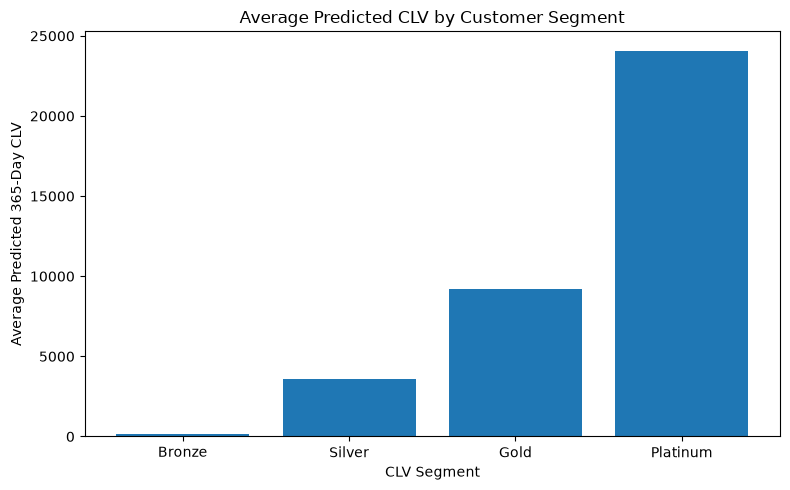

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    segment_summary["clv_segment"].astype(str),
    segment_summary["avg_clv_365d"]
)
plt.xlabel("CLV Segment")
plt.ylabel("Average Predicted 365-Day CLV")
plt.title("Average Predicted CLV by Customer Segment")
plt.tight_layout()
plt.show()

In [142]:
top20_clv = (
    combined[
        ["customer_id", "segment", "clv_365d",
         "probability_alive", "predicted_purchases_365d",
         "expected_average_profit"]
    ]
    .dropna(subset=["clv_365d"])
    .sort_values("clv_365d", ascending=False)
    .head(20)
)

display(top20_clv)

,customer_id,segment,clv_365d,probability_alive,predicted_purchases_365d,expected_average_profit
53,CUST000058,Champions,208824.090262,0.999924,290.331798,719.260142
2563,CUST002744,Champions,171215.149271,0.999895,230.952388,741.343924
3584,CUST003831,Champions,111196.372245,0.999855,165.810270,670.624157
6312,CUST006740,Champions,111177.275452,0.999826,164.078713,677.585004
7508,CUST008014,Champions,107439.626460,0.998868,147.361541,729.088648
8029,CUST008575,Champions,105877.149369,0.999478,166.267964,636.786228
2012,CUST002154,Champions,102986.354264,0.999558,144.065286,714.858918
7583,CUST008097,Champions,100814.299223,0.998747,149.190705,675.741156
4533,CUST004846,Champions,99970.251223,0.999819,152.268636,656.538694
2213,CUST002370,Champions,96020.566771,0.999851,144.393725,664.991271


In [143]:
total_revenue = clv_transactions["net_revenue"].sum()
total_transactions = clv_transactions["order_id"].nunique()
total_customers = clv_transactions["customer_id"].nunique()

apv = total_revenue / total_transactions
pf = total_transactions / total_customers

analysis_date = clv_transactions["order_date"].max()

last_purchase = (
    clv_transactions.groupby("customer_id")["order_date"]
    .max()
)

inactive_90 = (analysis_date - last_purchase).dt.days > 90

churn_rate = inactive_90.sum() / total_customers

traditional_clv = (apv * pf) / churn_rate

print("Average Purchase Value:", round(apv, 2))
print("Purchase Frequency:", round(pf, 2))
print("90-Day Churn Rate:", round(churn_rate, 4))
print("Traditional CLV:", round(traditional_clv, 2))

Average Purchase Value: 689.52
Purchase Frequency: 35.42
90-Day Churn Rate: 0.3241
Traditional CLV: 75342.36


In [148]:
print("BG/NBD Holdout Validation")
print("-------------------------")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))
print("Correlation:", round(correlation, 4))
print("Predicted purchases:", round(validation_final["predicted_purchases_holdout"].sum(), 2))
print("Actual purchases:", validation_final["actual_purchases"].sum())

BG/NBD Holdout Validation
-------------------------
MAE : 1.334
RMSE: 1.9881
R²  : 0.77
Correlation: 0.8779
Predicted purchases: 29540.86
Actual purchases: 28517.0


In [151]:
import pandas as pd
import os

# Find the project folder automatically
for root, dirs, files in os.walk(".", topdown=True):
    if "CUSTOMER.csv" in files:
        data_path = root
        break

print("Using data folder:", data_path)

customer = pd.read_csv(os.path.join(data_path, "CUSTOMER.csv"))
order_item = pd.read_csv(os.path.join(data_path, "ORDER_ITEM.csv"))
product = pd.read_csv(os.path.join(data_path, "PRODUCT.csv"))
category = pd.read_csv(os.path.join(data_path, "CATEGORY.csv"))

print("\nCUSTOMER:", customer.shape)
print(customer.columns.tolist())

print("\nORDER_ITEM:", order_item.shape)
print(order_item.columns.tolist())

print("\nPRODUCT:", product.shape)
print(product.columns.tolist())

print("\nCATEGORY:", category.shape)
print(category.columns.tolist())

Using data folder: .\data

CUSTOMER: (10000, 6)
['customer_id', 'signup_date', 'city', 'state', 'segment', 'status']

ORDER_ITEM: (1048575, 6)
['order_item_id', 'order_id', 'product_id', 'promo_id', 'quantity', 'item_discount']

PRODUCT: (200, 4)
['product_id', 'category_id', 'brand', 'sku_name']

CATEGORY: (10, 2)
['category_id', 'category_name']


In [153]:
# ============================================================
# PRODUCT / CATEGORY PREFERENCES BY CLV SEGMENT
# ============================================================

# Create order -> customer mapping from our existing CLV transaction data
order_customer = (
    clv_transactions[["order_id", "customer_id"]]
    .drop_duplicates()
)

# Join order items -> customer
product_items = order_item.merge(
    order_customer,
    on="order_id",
    how="inner"
)

# Join -> product
product_items = product_items.merge(
    product[["product_id", "category_id"]],
    on="product_id",
    how="left"
)

# Join -> category
product_items = product_items.merge(
    category[["category_id", "category_name"]],
    on="category_id",
    how="left"
)

# Add CLV segment
product_items = product_items.merge(
    segmentation[["customer_id", "clv_segment"]],
    on="customer_id",
    how="inner"
)

# Category preferences
category_summary = (
    product_items
    .groupby(
        ["clv_segment", "category_name"],
        observed=True
    )
    .agg(
        quantity=("quantity", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
    .sort_values(
        ["clv_segment", "quantity"],
        ascending=[True, False]
    )
)

print("=== TOP 5 PRODUCT CATEGORIES BY CLV SEGMENT ===")

display(
    category_summary
    .groupby("clv_segment", observed=True)
    .head(5)
)

=== TOP 5 PRODUCT CATEGORIES BY CLV SEGMENT ===


,clv_segment,category_name,quantity,orders,customers
0,Bronze,Beverages (Coffee/Malt),26690,15567,1778
5,Bronze,Dairy & Nutrition,20731,12802,1731
3,Bronze,Confectionery,17813,11247,1675
4,Bronze,Culinary (Soups/Seasonings),14928,9675,1629
1,Bronze,Bottled Water,14771,9532,1607
10,Silver,Beverages (Coffee/Malt),31394,18446,2752
15,Silver,Dairy & Nutrition,24341,15092,2728
13,Silver,Confectionery,21096,13316,2684
14,Silver,Culinary (Soups/Seasonings),17873,11636,2664
11,Silver,Bottled Water,17450,11301,2655
